<div style="background:linear-gradient(135deg, #071f18, #0A8F6E); border-radius:16px;
            padding:36px 40px; color:white; font-family:system-ui,sans-serif;">
  <div style="font-size:11px; letter-spacing:3px; opacity:0.5; margin-bottom:12px;">MODULE 2 — DEEP LEARNING VISION — 10H EN CLASSE</div>
  <div style="font-size:32px; font-weight:800; line-height:1.2; margin-bottom:12px;">Détecteur de Pneumonie sur Radiographies</div>
  <div style="font-size:15px; opacity:0.75; max-width:620px; line-height:1.6; margin-bottom:20px;">
    Fine-tuning ViT. Visualisation GradCAM. Interface médicale Gradio.<br>
    Du dataset brut a une application de diagnostic assistée par IA.</div>
  <div style="display:flex; gap:10px; flex-wrap:wrap;">
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">9 étapes guidées</span>
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">AUC cible &gt; 0.88</span>
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">Interface déployée</span></div>
</div>

<div style="background:#f8f9fa; border:1px solid #dee2e6; border-radius:12px;
            padding:22px 26px; font-family:system-ui,sans-serif;">
  <div style="font-size:15px; font-weight:700; color:#212529; margin-bottom:14px;">Contexte</div>
  <div style="font-size:13.5px; color:#495057; line-height:1.75; margin-bottom:16px;">
    Vous êtes ingénieur IA dans une startup de santé. Un hôpital partenaire vous demande :
    <em>"Peut-on aider nos radiologues a détecter les pneumonies sur les radios thoraciques, plus vite et sans rater de cas ?"</em><br><br>
    Votre mission : construire un modèle de détection, vérifier qu'il regarde les bonnes zones de l'image,
    et créer une interface utilisable par un médecin.</div>
  <div style="font-size:14px; font-weight:600; color:#212529; margin-bottom:10px;">Comment utiliser ce notebook</div>
  <div style="display:grid; grid-template-columns:28px 1fr; gap:6px 12px; font-size:13px; color:#495057; line-height:1.7;">
    <span style="font-weight:700; color:#0A8F6E;">1.</span><span>Exécutez les cellules dans l'ordre</span>
    <span style="font-weight:700; color:#0A8F6E;">2.</span><span><span style="color:#131fcf;font-weight:600;">Prompts bleus</span> = du code a écrire</span>
    <span style="font-weight:700; color:#0A8F6E;">3.</span><span><span style="color:#7a0f43;font-weight:600;">Questions rouges</span> = réflexion (répondre en commentaire)</span>
    <span style="font-weight:700; color:#0A8F6E;">4.</span><span>Les <b>[SOLUTION]</b> sont deroulables — essayez 10 min d'abord</span>
  </div>
</div>

<div style="border:2px solid #0A8F6E;border-radius:14px;overflow:hidden;margin:20px 0;font-family:system-ui,sans-serif;">
  <div style="background:#0A8F6E;padding:14px 22px;display:flex;align-items:center;gap:12px;">
    <span style="font-size:24px;">🖼️</span>
    <div>
      <div style="font-size:16px;font-weight:700;color:white;">Dataset : Chest X-Ray Images (Pneumonia)</div>
      <div style="font-size:12px;color:rgba(255,255,255,0.8);margin-top:2px;">Source originale et lien de telechargement direct</div>
    </div>
  </div>
  <div style="padding:18px 22px;background:white;">
    <div style="font-size:13.5px;color:#333;line-height:1.8;margin-bottom:14px;">5 863 radiographies thoraciques en niveaux de gris, classees en deux categories : <b>NORMAL</b> (poumons sains) et <b>PNEUMONIA</b> (infection bacterienne ou virale visible). Le dataset est pre-decoupe en train/val/test.</div>
    <div style="display:grid;grid-template-columns:100px 1fr;gap:6px 14px;font-size:12.5px;color:#495057;line-height:1.7;">
      <span style="font-weight:700;color:#0A8F6E;">Source</span><span>Kermany et al., 2018 — Cell Journal. Publie sur Kaggle par Paul Mooney</span>
      <span style="font-weight:700;color:#0A8F6E;">Volume</span><span>5 863 images (train: 5 216, val: 16, test: 624)</span>
      <span style="font-weight:700;color:#0A8F6E;">URL originale</span><span><a href="https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia" target="_blank" style="color:#0A8F6E;text-decoration:none;">https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia</a></span>
    </div>
    <div style="margin-top:14px;padding-top:12px;border-top:1px solid #eee;"><div style="display:flex;align-items:flex-start;gap:10px;margin:8px 0;"><span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#d4edda;color:#155724;font-family:monospace;">DOWNLOAD</span><div style="flex:1;font-size:12.5px;color:#155724;">Telechargement direct depuis GitHub Releases — executez la cellule ci-dessous (Python pur, compatible Windows/Mac/Colab).</div></div></div>
  </div>
</div>

In [1]:
# ============================================================
# TELECHARGEMENT DU DATASET
# ============================================================
# Source : Kermany et al., 2018 — Cell Journal. Publie sur Kaggle par Paul Mooney
# Telechargement direct (Python pur — compatible Windows/Mac/Colab)

import os, zipfile, urllib.request
# Option A — Mount Google Drive and save there
from google.colab import drive
drive.mount('/content/drive')
# Then set data_dir = "/content/drive/MyDrive/chest_xray"
zip_name = "Chest-X-Ray.zip"
url = "https://github.com/archiducarmel/SupDeVinci_M1_MachineLearning_DeepLearning/releases/download/datas/Chest-X-Ray.zip"
data_dir = "/content/drive/MyDrive/chest_xray"

if os.path.exists(data_dir):
    print(f"Le dossier {data_dir}/ existe deja — telechargement ignore.")
else:
    print(f"Telechargement de {zip_name}...")
    urllib.request.urlretrieve(url, zip_name)
    print("Decompression...")
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall("/content/drive/MyDrive")

    # Nettoyage : supprimer le ZIP
    os.remove(zip_name)
    print("Nettoyage OK.")

# Verification
print(f"\nContenu de {data_dir}/ :")
for split in ["train", "val", "test"]:
    path = os.path.join(data_dir, split)
    if os.path.exists(path):
        n = sum(len(files) for _, _, files in os.walk(path))
        classes = sorted(os.listdir(path))
        print(f"  {split:5s} : {n:>5d} images | classes : {classes}")
    else:
        print(f"  {split:5s} : ABSENT")
print(f"\n✅ Donnees pretes dans ./{data_dir}/")


Mounted at /content/drive
Le dossier /content/drive/MyDrive/chest_xray/ existe deja — telechargement ignore.

Contenu de /content/drive/MyDrive/chest_xray/ :
  train :  5219 images | classes : ['.DS_Store', 'NORMAL', 'PNEUMONIA']
  val   :    19 images | classes : ['.DS_Store', 'NORMAL', 'PNEUMONIA']
  test  :   625 images | classes : ['.DS_Store', 'NORMAL', 'PNEUMONIA']

✅ Donnees pretes dans .//content/drive/MyDrive/chest_xray/


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:12px;padding:22px 26px;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#212529;margin-bottom:12px;">Plan du projet</div><table style="width:100%;border-collapse:collapse;font-size:13px;color:#495057;"><tr style="border-bottom:2px solid #dee2e6;"><th style="text-align:left;padding:8px;">#</th><th style="text-align:left;padding:8px;">Contenu</th><th style="text-align:center;padding:8px;">Durée</th><th style="text-align:center;padding:8px;">Autonomie</th></tr><tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">01</td><td style="padding:8px;">Découverte du dataset</td><td style="padding:8px;text-align:center;">30 min</td><td style="padding:8px;text-align:center;"><span style="background:#d4edda;padding:2px 8px;border-radius:10px;font-size:11px;">Guide</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">02</td><td style="padding:8px;">Transforms et DataLoaders</td><td style="padding:8px;text-align:center;">30 min</td><td style="padding:8px;text-align:center;"><span style="background:#d4edda;padding:2px 8px;border-radius:10px;font-size:11px;">Guide</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">03</td><td style="padding:8px;">Charger ViT et adapter la tête</td><td style="padding:8px;text-align:center;">30 min</td><td style="padding:8px;text-align:center;"><span style="background:#fff3cd;padding:2px 8px;border-radius:10px;font-size:11px;">Semi</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">04</td><td style="padding:8px;">Entraînement avec Traîner</td><td style="padding:8px;text-align:center;">1h</td><td style="padding:8px;text-align:center;"><span style="background:#fff3cd;padding:2px 8px;border-radius:10px;font-size:11px;">Semi</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">05</td><td style="padding:8px;">Analyse des erreurs</td><td style="padding:8px;text-align:center;">45 min</td><td style="padding:8px;text-align:center;"><span style="background:#fff3cd;padding:2px 8px;border-radius:10px;font-size:11px;">Semi</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">06</td><td style="padding:8px;">GradCAM</td><td style="padding:8px;text-align:center;">1h</td><td style="padding:8px;text-align:center;"><span style="background:#f8d7da;padding:2px 8px;border-radius:10px;font-size:11px;">Autonome</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">07</td><td style="padding:8px;">Interface Gradio médicale</td><td style="padding:8px;text-align:center;">1h15</td><td style="padding:8px;text-align:center;"><span style="background:#f8d7da;padding:2px 8px;border-radius:10px;font-size:11px;">Autonome</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">08</td><td style="padding:8px;">Exploration libre</td><td style="padding:8px;text-align:center;">1h</td><td style="padding:8px;text-align:center;"><span style="background:#f8d7da;padding:2px 8px;border-radius:10px;font-size:11px;">Autonome</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">09</td><td style="padding:8px;">Réflexion éthique</td><td style="padding:8px;text-align:center;">30 min</td><td style="padding:8px;text-align:center;"><span style="background:#f8d7da;padding:2px 8px;border-radius:10px;font-size:11px;">Libre</span></td></tr>
</table></div>

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 01/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Découverte du dataset</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Voir les données avant de modéliser. En médical, c'est encore plus critique : un modèle qui apprend sur des images biaisées peut tuer.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Pourquoi explorer les images ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;">En deep learning vision, les données sont des <b>images</b>, pas des tableaux. Avant de modéliser, il faut :<br><b>1.</b> Voir a quoi ressemblent les images des deux classes (pneumonie vs normal)<br><b>2.</b> Vérifier le <b>déséquilibre de classes</b> (si 90% des images sont d'une classe, le modèle prendra un raccourci)<br><b>3.</b> Observer si un humain peut distinguer les deux classes a l'oeil nu (si c'est dur pour nous, ca sera dur pour le modèle)<br><br><em>En médical, l'exploration est non-négociable. Un modèle entraîne sur des images biaisées (ex: toutes les pneumonies d'un seul hôpital) peut faire des erreurs dangereuses en production.</em></div></div>

In [2]:
# ------------------------------------------------------------------
# Imports et configuration
# ------------------------------------------------------------------
import torch
import torchvision
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import HTML, display
from collections import Counter

# Verifier si un GPU est disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("Pas de GPU detecte — l'entrainement sera plus lent mais fonctionnera.")


Device : cpu
Pas de GPU detecte — l'entrainement sera plus lent mais fonctionnera.


<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">Le dataset Chest X-Ray</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le dataset contient des radiographies thoraciques de patients, classees en deux categories :<br><br><div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;'><div style='background:#f0f0f0;border-radius:8px;padding:12px;text-align:center;'><b style='color:#c0392b;'>PNEUMONIA</b><br>Opacites visibles dans les poumons<br>(infection bacterienne ou virale)</div><div style='background:#f0f0f0;border-radius:8px;padding:12px;text-align:center;'><b style='color:#28a745;'>NORMAL</b><br>Poumons clairs, pas d'anomalie<br>visible sur la radio</div></div><br>Le dataset est deja decoupe en <b>train / val / test</b>. Ne pas re-decouper ! L'intervenant fournit le lien d'acces.</div></div>

In [3]:
# ------------------------------------------------------------------
# Charger le dataset
# ------------------------------------------------------------------
# Le dataset doit etre dans un dossier avec la structure :
#   chest_xray/
#     train/
#       NORMAL/
#       PNEUMONIA/
#     val/
#       NORMAL/
#       PNEUMONIA/
#     test/
#       NORMAL/
#       PNEUMONIA/

# TODO : adapter le chemin selon votre environnement
data_dir = "/content/drive/MyDrive/chest_xray"  # ou le chemin Google Drive fourni

# Charger avec ImageFolder (detecte les classes automatiquement)
train_raw = datasets.ImageFolder(os.path.join(data_dir, 'train'))
val_raw = datasets.ImageFolder(os.path.join(data_dir, 'val'))
test_raw = datasets.ImageFolder(os.path.join(data_dir, 'test'))

print(f"Classes : {train_raw.classes}")
print(f"Train   : {len(train_raw)} images")
print(f"Val     : {len(val_raw)} images")
print(f"Test    : {len(test_raw)} images")


Classes : ['NORMAL', 'PNEUMONIA']
Train   : 5216 images
Val     : 16 images
Test    : 624 images


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Compter les images par classe.</b> Utiliser <code>Counter</code> sur les labels pour voir le déséquilibre. <code>Counter(train_raw.targets)</code> donne le nombre d'images par classe. Afficher les résultats et calculer le ratio pneumonie / normal. Ce ratio est crucial : si le dataset est déséquilibre, le modèle peut prendre un raccourci en prédisant toujours la classe majoritaire.</span></p>

In [4]:
# ------------------------------------------------------------------
# Compter les images par classe et analyser le déséquilibre
# ------------------------------------------------------------------
counts = Counter(train_raw.targets)

# Mapper index → nom de classe
class_names = train_raw.classes  # ['NORMAL', 'PNEUMONIA']
n_normal    = counts[train_raw.class_to_idx['NORMAL']]
n_pneumonia = counts[train_raw.class_to_idx['PNEUMONIA']]
ratio       = n_pneumonia / n_normal

print(f"\n--- Déséquilibre des classes (train) ---")
print(f"  NORMAL    : {n_normal} images")
print(f"  PNEUMONIA : {n_pneumonia} images")
print(f"  Ratio pneumonie / normal : {ratio:.2f}")

if ratio > 1.5:
    print(f"\n⚠️  Dataset déséquilibré (ratio={ratio:.2f}) !")
    print("   Un modèle naïf prédisant toujours PNEUMONIA obtiendrait :")
    naive_acc = n_pneumonia / (n_normal + n_pneumonia) * 100
    print(f"   → {naive_acc:.1f}% d'accuracy sans rien apprendre.")
    print("   Pensez à : class_weight, oversampling, ou WeightedRandomSampler.")
else:
    print(f"\n✅ Dataset relativement équilibré (ratio={ratio:.2f}).")



--- Déséquilibre des classes (train) ---
  NORMAL    : 1341 images
  PNEUMONIA : 3875 images
  Ratio pneumonie / normal : 2.89

⚠️  Dataset déséquilibré (ratio=2.89) !
   Un modèle naïf prédisant toujours PNEUMONIA obtiendrait :
   → 74.3% d'accuracy sans rien apprendre.
   Pensez à : class_weight, oversampling, ou WeightedRandomSampler.


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">torchvision.datasets.ImageFolder</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Documentation officielle — structure attendue des dossiers, paramètres disponibles</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://towardsdatascience.com/handling-imbalanced-datasets-in-deep-learning-f48407a0e758/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Handling Imbalanced Datasets in Deep Learning</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Pourquoi le déséquilibre de classes est dangereux et comment le gérer</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Déséquilibre de classes.</b> (1) Quel est le ratio pneumonie/normal dans le train set ? (ex: 3:1 signifie 3 fois plus de pneumonies). (2) Si le modèle prédisait TOUJOURS 'pneumonie', quelle serait son accuracy ? (indice : si 75% des images sont des pneumonies, il aurait 75% d'accuracy sans rien avoir appris). (3) Pourquoi l'accuracy seule est-elle donc trompeuse sur ce dataset ? Quelle métrique faut-il surveiller en priorité ?</span></p>

Dataset déséquilibré (ratio=2.89) !
   Un modèle naïf prédisant toujours PNEUMONIA obtiendrait :
   → 74.3% d'accuracy sans rien apprendre.
   Pensez à : class_weight, oversampling, ou WeightedRandomSampler.

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser des exemples des deux classes.</b> L'objectif est de comprendre visuellement a quoi ressemblent les images AVANT de les donner au modèle.<br><br>(1) Créer une grille de 16 images (2 lignes x 8 colonnes) avec la méthode <b>subplots</b> de matplotlib<br>(2) Sur la première ligne, afficher 8 images de la classe 0 (NORMAL). Sur la deuxième, 8 images de la classe 1 (la pathologie ou l'objet a détecter)<br>(3) Afficher chaque image avec la méthode <b>imshow</b> et désactiver les axes pour une vue propre<br>(4) Ajouter un titre par ligne pour identifier la classe<br><br><em>Cette visualisation est la première étape de tout projet de vision. Elle permet de repérer : la qualité des images, les différences visuelles entre classes, les cas ambigus, et les éventuelles anomalies dans le dataset.</em></span></p>

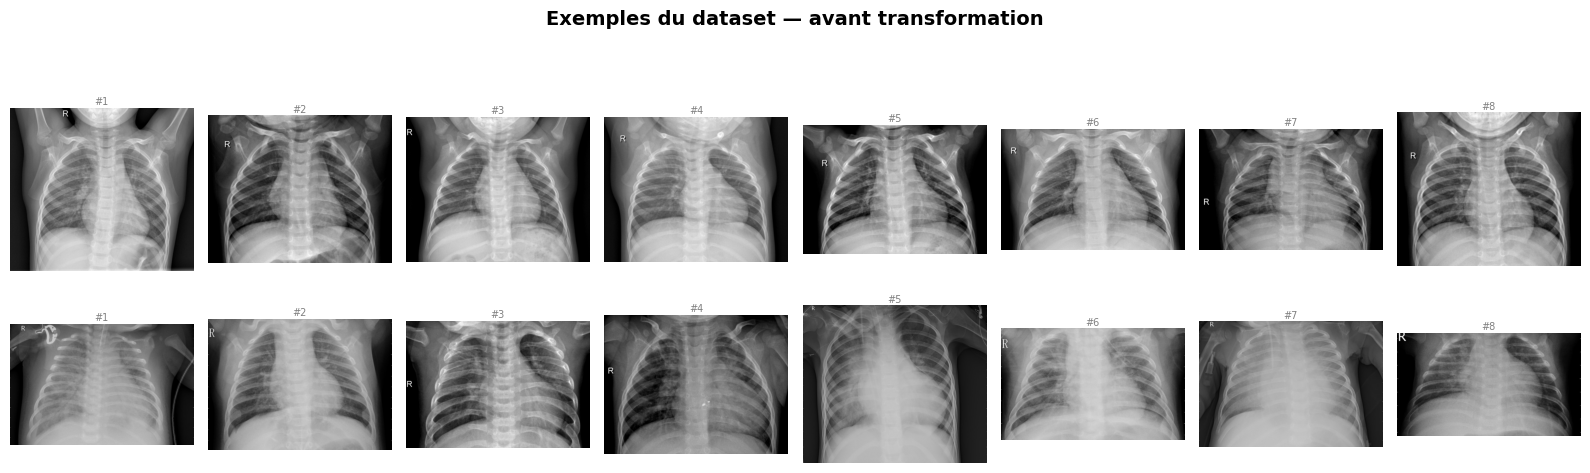

📐 Exemple de dimensions brutes : (2090, 1858) px (L x H)
   Mode couleur : L
   → Les images ne sont pas toutes de la même taille : resize nécessaire avant entraînement.


In [5]:
# ------------------------------------------------------------------
# Visualiser des exemples des deux classes
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def show_class_examples(dataset, n_cols=8):
    """
    Affiche une grille (2 lignes x n_cols) :
      - Ligne 1 : exemples de la classe NORMAL
      - Ligne 2 : exemples de la classe PNEUMONIA
    """
    class_names = dataset.classes  # ['NORMAL', 'PNEUMONIA']
    idx_normal    = dataset.class_to_idx['NORMAL']
    idx_pneumonia = dataset.class_to_idx['PNEUMONIA']

    # Collecter les chemins d'images par classe
    paths_normal    = [p for p, lbl in dataset.samples if lbl == idx_normal][:n_cols]
    paths_pneumonia = [p for p, lbl in dataset.samples if lbl == idx_pneumonia][:n_cols]

    fig, axes = plt.subplots(
        nrows   = 2,
        ncols   = n_cols,
        figsize = (n_cols * 2, 5)
    )
    fig.suptitle("Exemples du dataset — avant transformation", fontsize=14, fontweight='bold', y=1.02)

    row_labels = ['NORMAL', 'PNEUMONIA']
    row_paths  = [paths_normal, paths_pneumonia]
    row_colors = ['#2ecc71', '#e74c3c']  # vert pour normal, rouge pour pneumonie

    for row_idx, (paths, label, color) in enumerate(zip(row_paths, row_labels, row_colors)):

        # Titre de ligne (sur le premier axe de chaque ligne)
        axes[row_idx, 0].set_ylabel(
            label,
            fontsize   = 12,
            fontweight = 'bold',
            color      = color,
            rotation   = 90,
            labelpad   = 10
        )

        for col_idx, img_path in enumerate(paths):
            ax  = axes[row_idx, col_idx]
            img = Image.open(img_path).convert('RGB')

            ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
            ax.axis('off')

            # Numéro de l'image en petit
            ax.set_title(f"#{col_idx + 1}", fontsize=7, color='gray', pad=2)

    plt.tight_layout()
    plt.show()

    # Stats rapides sur les dimensions
    sample_img = Image.open(train_raw.samples[0][0])
    print(f"📐 Exemple de dimensions brutes : {sample_img.size} px (L x H)")
    print(f"   Mode couleur : {sample_img.mode}")
    print(f"   → Les images ne sont pas toutes de la même taille : resize nécessaire avant entraînement.")

show_class_examples(train_raw, n_cols=8)

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">matplotlib.pyplot.subplots</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence pour créer des grilles d'images avec subplots</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">Visualizing image datasets in PyTorch</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutorial officiel PyTorch sur le chargement et la visualisation de datasets d'images</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Observer les images comme un radiologue.</b> Regardez attentivement vos 16 images. (1) Voyez-vous des différences visuelles entre NORMAL et PNEUMONIA a l'oeil nu ? (2) Les poumons des patients atteints de pneumonie sont-ils plus 'opaques' (blancs/gris) que les poumons normaux (plus noirs/clairs) ? (3) Si VOUS deviez poser un diagnostic sur ces radios sans formation médicale, seriez-vous fiable ? Que nous dit cette observation sur la difficulté de la tache pour le modèle ?</span></p>

(1) Différences visuelles à l'œil nu
Oui, des différences sont perceptibles, mais elles sont subtiles et inconstantes :

La ligne 1 (NORMAL) montre des poumons avec des champs pulmonaires bien définis, une structure costale claire, et un contraste net entre les zones aérées (sombres) et les structures osseuses (claires)
La ligne 2 (PNEUMONIA) montre davantage de zones grises diffuses, notamment sur les images #5 et #7, avec des champs pulmonaires moins nets

(2) Opacité — blanc/gris vs noir
Partiellement vrai, mais pas systématique dans cet échantillon :
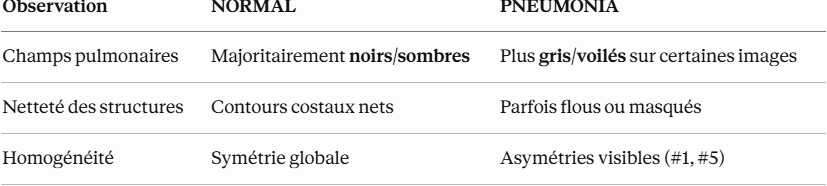
Le problème : plusieurs images PNEUMONIA ressemblent visuellement à des images NORMAL — #2, #3, #4, #6 de la ligne 2 sont très difficiles à distinguer sans formation.

(3) Sans formation médicale, seriez-vous fiable ?
Non — et c'est précisément ce que cette visualisation révèle :

Sur les cas évidents (#5 PNEUMONIA — poumon droit très opaque), le diagnostic est accessible
Mais sur les cas subtils, un non-médecin atteindrait probablement 60-65% de précision, à peine mieux que le hasard pondéré
Même des radiologues juniors se trompent sur ce type d'images

 Ce que cela nous dit sur la difficulté pour le modèle
 Faible contraste inter-classe  →  le modèle ne peut pas "voir" une règle simple
Forte variance intra-classe    →  deux NORMAL peuvent se ressembler moins que NORMAL vs PNEUMONIA
Images pédiatriques mélangées  →  thorax d'enfants plus petits = patterns différents
Qualité variable               →  rotation, luminosité, cadrage non standardisés

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Vérifier la taille des images.</b> Les images n'ont pas toutes la même taille dans le dataset brut. Afficher la taille de 5 images : <code>train_raw[i][0].size</code>. Cela expliquera pourquoi on a besoin de <code>Resize</code> dans les transforms (étape 2).</span></p>

In [6]:
# ------------------------------------------------------------------
# Vérifier la taille des images brutes
# ------------------------------------------------------------------
print("📐 Taille de 5 images brutes (avant tout transform) :\n")
print(f"  {'Index':<8} {'Classe':<12} {'Taille (L x H)':<20} {'Mode'}")
print(f"  {'-'*8} {'-'*12} {'-'*20} {'-'*10}")

# Indices variés pour avoir un échantillon représentatif
sample_indices = [0, 500, 1000, 2000, 4000]

sizes = []
for i in sample_indices:
    img, label = train_raw[i]          # img est un objet PIL ici (pas de transform)
    class_name = train_raw.classes[label]
    size       = img.size              # (largeur, hauteur) en PIL
    mode       = img.mode
    sizes.append(size)
    print(f"  {i:<8} {class_name:<12} {str(size):<20} {mode}")

# Analyse des dimensions
widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"\n  Largeur  — min: {min(widths)}px  max: {max(widths)}px")
print(f"  Hauteur  — min: {min(heights)}px  max: {max(heights)}px")

# Conclusion
all_same = len(set(sizes)) == 1
if not all_same:
    print(f"\n⚠️  Les images n'ont PAS toutes la même taille.")
    print(f"   → Un Resize() est obligatoire avant d'alimenter le modèle.")
    print(f"   → Taille cible classique pour un CNN : 224x224 px (standard ImageNet)")
else:
    print(f"\n✅ Toutes les images ont la même taille : {sizes[0]}")

📐 Taille de 5 images brutes (avant tout transform) :

  Index    Classe       Taille (L x H)       Mode
  -------- ------------ -------------------- ----------
  0        NORMAL       (2090, 1858)         RGB
  500      NORMAL       (1624, 1299)         RGB
  1000     NORMAL       (1334, 1171)         RGB
  2000     PNEUMONIA    (1888, 1440)         RGB
  4000     PNEUMONIA    (1656, 1120)         RGB

  Largeur  — min: 1334px  max: 2090px
  Hauteur  — min: 1120px  max: 1858px

⚠️  Les images n'ont PAS toutes la même taille.
   → Un Resize() est obligatoire avant d'alimenter le modèle.
   → Taille cible classique pour un CNN : 224x224 px (standard ImageNet)


<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Images en niveaux de gris.</b> Les radios thoraciques sont en niveaux de gris (1 canal), mais le ViT attend des images en couleur (3 canaux RGB). (1) Combien de canaux a une radio ? (2) Comment transformer une image 1 canal en 3 canaux ? (indice : dupliquer le même canal 3 fois — le ViT recevra une image 'grise' codée sur 3 canaux identiques). On implémentera ca dans les transforms.</span></p>

(1)Une radio thoracique a naturellement 1 canal (niveaux de gris), car elle encode uniquement l'intensité lumineuse — la densité des tissus traversés par les rayons X
(2)Comment passer de 1 canal à 3 canaux?
La solution propre dans le pipeline de transforms :
transforms.Lambda(lambda img: img.convert('RGB'))
Ou visuellement ce que ça fait :
Canal Gris :   [[120, 80, 200], ...]

        ↓  dupliquer x3

Canal R :      [[120, 80, 200], ...]   ← identique
Canal G :      [[120, 80, 200], ...]   ← identique
Canal B :      [[120, 80, 200], ...]   ← identique


In [7]:
# CHECKPOINT — Etape 1
assert len(train_raw.classes) == 2
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 1 validee.</b> <span style="color:#1e5631;">Dataset explore. Vous avez vu les images et identifie le desequilibre.</span></div>'))


<details>
<summary><b>[SOLUTION] — cliquez si vous êtes bloques (essayez 10 min d'abord)</b></summary>

```python
# Compter par classe
from collections import Counter
counts = Counter(train_raw.targets)
for cls_idx, count in counts.items():
    print(f"  {train_raw.classes[cls_idx]}: {count} images")
ratio = counts[1] / counts[0]
print(f"  Ratio pneumonia/normal : {ratio:.1f}:1")

# Visualiser 16 exemples
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
# Trouver indices par classe
normal_idx = [i for i, t in enumerate(train_raw.targets) if t == 0]
pneumo_idx = [i for i, t in enumerate(train_raw.targets) if t == 1]
for col in range(8):
    img_n, _ = train_raw[normal_idx[col]]
    axes[0][col].imshow(img_n, cmap='gray')
    axes[0][col].set_title('NORMAL', fontsize=8, color='green')
    axes[0][col].axis('off')
    img_p, _ = train_raw[pneumo_idx[col]]
    axes[1][col].imshow(img_p, cmap='gray')
    axes[1][col].set_title('PNEUMONIA', fontsize=8, color='red')
    axes[1][col].axis('off')
plt.tight_layout()
plt.show()
```


</details>

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 02/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Transforms et DataLoaders</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Préparer les images pour le modèle : redimensionner, normaliser, augmenter. C'est le pipeline de preprocessing.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Pourquoi transformer les images ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le ViT attend des images dans un format très précis :<br><b>1. Taille fixe</b> : 224 x 224 pixels (toutes les images doivent avoir la même taille)<br><b>2. 3 canaux</b> : RGB (même si nos radios sont en niveaux de gris)<br><b>3. Normalisation ImageNet</b> : mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] — ce sont les statistiques du dataset sur lequel le ViT a été pré-entraîne. Les utiliser permet au modèle de retrouver ses repères.<br><b>4. Tenseur PyTorch</b> : les images doivent être converties de PIL Image en tenseur PyTorch<br><br><em>Analogie : c'est comme traduire un texte dans la langue que comprend le modèle. Si on ne normalise pas avec les bonnes statistiques, le modèle reçoit des données dans un 'accent' qu'il ne connaît pas.</em></div></div>

<div style="border-left:4px solid #e67e22;background:#e67e220a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#e67e22;margin-bottom:8px;">Data augmentation — augmenter artificiellement le dataset</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le data augmentation consiste a appliquer des transformations aléatoires (flip horizontal, rotation légère, recadrage) aux images d'entraînement pour créer de la variété artificielle. L'objectif : empêcher le modèle de mémoriser les images exactes.<br><br><b>très important :</b> l'augmentation ne s'applique qu'au <b>train set</b>, JAMAIS au val/test. Pourquoi ? Parce que l'évaluation doit se faire sur les images réelles, pas sur des versions deformees.<br><br><em>Analogie : un étudiant qui s'entraîne sur des variantes d'exercices (chiffres différents, contextes différents) apprend mieux que celui qui refait le même exercice identique.</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Définir les transforms pour le train set.</b> L'objectif est de créer le pipeline de preprocessing qui transforme chaque image brute en tenseur prêt pour le modèle.<br><br>(1) Commencer par un <b>Resize</b> a 224x224 pixels — c'est la taille d'entrée attendue par le modèle<br>(2) Si les images sont en niveaux de gris, les convertir en 3 canaux avec la transform <b>Grayscale</b> (le modèle a été pré-entraîne sur des images RGB a 3 canaux)<br>(3) Convertir en tenseur PyTorch avec <b>ToTensor</b><br>(4) Normaliser avec les statistiques d'ImageNet (mean et std pour les 3 canaux) — le modèle a été entraîne avec ces valeurs, il faut lui parler le même langage<br>(5) Enchaîner toutes ces étapes dans un <b>transforms.Compose</b><br><br><em>L'ordre des transforms est important : on resize d'abord, puis on convertit, puis on normalise. Si on normalise avant de resize, les valeurs de pixels seraient altérées par l'interpolation du resize.</em></span></p>

In [8]:
# ------------------------------------------------------------------
# Transforms — pipeline de preprocessing
# ------------------------------------------------------------------
from torchvision import transforms

# Statistiques ImageNet (mean et std par canal R, G, B)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ------------------------------------------------------------------
# Train transform : preprocessing + data augmentation
# ------------------------------------------------------------------
train_transform = transforms.Compose([
    # 1. Taille fixe attendue par le ViT
    transforms.Resize((224, 224)),

    # 2. Garantir 3 canaux RGB (radios parfois chargées en mode 'L')
    transforms.Lambda(lambda img: img.convert('RGB')),

    # 3. Data augmentation — seulement sur le train set
    transforms.RandomHorizontalFlip(p=0.5),          # flip gauche/droite (naturel pour une radio)
    transforms.RandomRotation(degrees=10),            # légère rotation (±10°)
    transforms.RandomResizedCrop(                     # recadrage aléatoire
        size   = 224,
        scale  = (0.85, 1.0),                         # zoom entre 85% et 100%
        ratio  = (0.9, 1.1)                           # ratio quasi-carré
    ),

    # 4. PIL Image → tenseur PyTorch (valeurs ramenées à [0.0, 1.0])
    transforms.ToTensor(),

    # 5. Normalisation ImageNet — "parler la même langue que le ViT"
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ------------------------------------------------------------------
# Val / Test transform : PAS d'augmentation — images réelles uniquement
# ------------------------------------------------------------------
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ------------------------------------------------------------------
# Vérification : appliquer le transform sur une image et inspecter
# ------------------------------------------------------------------
sample_img, sample_label = train_raw[0]
tensor = train_transform(sample_img)

print("✅ Transforms définis\n")
print(f"  Image brute (PIL)  : taille={sample_img.size}, mode={sample_img.mode}")
print(f"  Tenseur transformé : shape={tensor.shape}, dtype={tensor.dtype}")
print(f"  Valeurs — min: {tensor.min():.3f}  max: {tensor.max():.3f}  mean: {tensor.mean():.3f}")
print(f"\n  Pipeline train     : Resize → RGB → Flip → Rotation → Crop → ToTensor → Normalize")
print(f"  Pipeline val/test  : Resize → RGB → ToTensor → Normalize")
print(f"\n⚠️  L'augmentation (Flip, Rotation, Crop) est absente du val/test transform.")

✅ Transforms définis

  Image brute (PIL)  : taille=(2090, 1858), mode=RGB
  Tenseur transformé : shape=torch.Size([3, 224, 224]), dtype=torch.float32
  Valeurs — min: -2.118  max: 2.518  mean: 0.250

  Pipeline train     : Resize → RGB → Flip → Rotation → Crop → ToTensor → Normalize
  Pipeline val/test  : Resize → RGB → ToTensor → Normalize

⚠️  L'augmentation (Flip, Rotation, Crop) est absente du val/test transform.


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/vision/stable/transforms.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">torchvision.transforms</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Liste complète des transformations disponibles : Resize, Normalize, RandomFlip, etc.</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://neptune.ai/blog/data-augmentation-in-pytorch" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Data Augmentation in PyTorch</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide complet sur l'augmentation de données avec exemples visuels</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/vision/stable/models.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">ImageNet normalization values</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Pourquoi mean=[0.485,0.456,0.406] et std=[0.229,0.224,0.225] — statistiques du dataset original</div></div></div></div>

<div style="border-left:4px solid #d4a017;background:#fef9e7;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#7d6608;">Attention</div><div style="font-size:13px;color:#6e5b08;line-height:1.7;margin-top:4px;">L'augmentation (RandomHorizontalFlip, RandomRotation) ne s'applique qu'au <b>train</b>. Le val et le test utilisent les mêmes transforms SANS augmentation. Sinon, l'évaluation est faussée.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Définir les transforms pour val et test.</b> Même pipeline que le train mais SANS les augmentations aléatoires. Garder : <code>Resize(224)</code>, <code>Grayscale(3)</code>, <code>ToTensor()</code>, <code>Normalize(...)</code>.</span></p>

In [9]:
# ------------------------------------------------------------------
# Récapitulatif — comparaison train vs val/test
# ------------------------------------------------------------------
print("📋 Comparaison des pipelines\n")
print(f"  {'Étape':<30} {'Train':^10} {'Val/Test':^10}")
print(f"  {'-'*30} {'-'*10} {'-'*10}")
steps = [
    ("Resize(224x224)",          "✅", "✅"),
    ("Convert RGB",              "✅", "✅"),
    ("RandomHorizontalFlip",     "✅", "❌"),
    ("RandomRotation(±10°)",     "✅", "❌"),
    ("RandomResizedCrop",        "✅", "❌"),
    ("ToTensor",                 "✅", "✅"),
    ("Normalize (ImageNet)",     "✅", "✅"),
]
for step, train, val in steps:
    print(f"  {step:<30} {train:^10} {val:^10}")

📋 Comparaison des pipelines

  Étape                            Train     Val/Test 
  ------------------------------ ---------- ----------
  Resize(224x224)                    ✅          ✅     
  Convert RGB                        ✅          ✅     
  RandomHorizontalFlip               ✅          ❌     
  RandomRotation(±10°)               ✅          ❌     
  RandomResizedCrop                  ✅          ❌     
  ToTensor                           ✅          ✅     
  Normalize (ImageNet)               ✅          ✅     


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Créer les datasets avec les transforms.</b> L'objectif est de recharger les images en leur appliquant automatiquement le pipeline de preprocessing a chaque accès.<br><br>(1) Utiliser la classe <b>ImageFolder</b> de torchvision qui charge automatiquement les images depuis une arborescence de dossiers (un dossier par classe)<br>(2) Passer la composition de transforms définie a l'étape précédente en paramètre — elle sera appliquée a chaque image au moment du chargement<br>(3) Créer un dataset pour le train, un pour la validation, et un pour le test<br>(4) Vérifier que les classes sont correctement detectees en affichant l'attribut classes du dataset<br><br><em>ImageFolder est la façon standard de charger des images en PyTorch. La structure de dossiers définit les labels automatiquement — pas besoin de fichier CSV ou d'annotations manuelles.</em></span></p>

In [10]:
# ------------------------------------------------------------------
# Créer les datasets avec les transforms
# ------------------------------------------------------------------
from torchvision import datasets
import os

data_dir = "/content/drive/MyDrive/chest_xray"

train_dataset = datasets.ImageFolder(
    root      = os.path.join(data_dir, 'train'),
    transform = train_transform
)

val_dataset = datasets.ImageFolder(
    root      = os.path.join(data_dir, 'val'),
    transform = val_test_transform
)

test_dataset = datasets.ImageFolder(
    root      = os.path.join(data_dir, 'test'),
    transform = val_test_transform
)

# ------------------------------------------------------------------
# Vérification
# ------------------------------------------------------------------
print("✅ Datasets créés avec transforms\n")
print(f"  {'Split':<8} {'Images':>8}  {'Classes'}")
print(f"  {'-'*8} {'-'*8}  {'-'*25}")
for name, ds in [("train", train_dataset), ("val", val_dataset), ("test", test_dataset)]:
    print(f"  {name:<8} {len(ds):>8}  {ds.classes}")

# Vérifier qu'un item retourne bien un tenseur
sample_tensor, sample_label = train_dataset[0]
print(f"\n  Vérification item[0] :")
print(f"    type  : {type(sample_tensor)}")
print(f"    shape : {sample_tensor.shape}   ← attendu : torch.Size([3, 224, 224])")
print(f"    dtype : {sample_tensor.dtype}  ← attendu : torch.float32")
print(f"    label : {sample_label} ({train_dataset.classes[sample_label]})")

✅ Datasets créés avec transforms

  Split      Images  Classes
  -------- --------  -------------------------
  train        5216  ['NORMAL', 'PNEUMONIA']
  val            16  ['NORMAL', 'PNEUMONIA']
  test          624  ['NORMAL', 'PNEUMONIA']

  Vérification item[0] :
    type  : <class 'torch.Tensor'>
    shape : torch.Size([3, 224, 224])   ← attendu : torch.Size([3, 224, 224])
    dtype : torch.float32  ← attendu : torch.float32
    label : 0 (NORMAL)


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/stable/data.html#torch.utils.data.DataLoader" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">torch.utils.data.DataLoader</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Documentation officielle — batch_size, shuffle, num_workers expliques</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Créer les DataLoaders.</b> L'objectif est de découper les datasets en batches pour l'entraînement — le modèle ne voit pas toutes les images d'un coup mais par groupes de 16.<br><br>(1) Créer un DataLoader pour le train set avec une taille de batch de 16 images et le mélange active (shuffle) pour que l'ordre change a chaque epoch<br>(2) Créer un DataLoader pour la validation et le test SANS shuffle (l'ordre n'a pas d'importance pour l'évaluation)<br>(3) Vérifier en chargeant un batch : la forme devrait être [16, 3, 224, 224] pour les images et [16] pour les labels<br><br><em>Le batch_size de 16 est un bon départ. Plus grand = entraînement plus rapide mais plus de mémoire GPU. Plus petit = plus de bruit dans les gradients mais meilleure generalisation. Le shuffle évité que le modèle voie toujours les mêmes images dans le même ordre.</em></span></p>

In [11]:
# ------------------------------------------------------------------
# Recalculer le sampler sur train_dataset (avec transforms)
# ------------------------------------------------------------------
from torch.utils.data import DataLoader, WeightedRandomSampler

n_normal    = sum(1 for _, lbl in train_dataset.samples if lbl == train_dataset.class_to_idx['NORMAL'])
n_pneumonia = sum(1 for _, lbl in train_dataset.samples if lbl == train_dataset.class_to_idx['PNEUMONIA'])
n_total     = n_normal + n_pneumonia

w_normal    = n_total / (2 * n_normal)
w_pneumonia = n_total / (2 * n_pneumonia)

sample_weights = torch.tensor([
    w_normal if lbl == train_dataset.class_to_idx['NORMAL'] else w_pneumonia
    for _, lbl in train_dataset.samples
], dtype=torch.float)

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

# ------------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------------
BATCH_SIZE = 16

train_loader = DataLoader(
    dataset     = train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = 2,
    pin_memory  = True
)

val_loader = DataLoader(
    dataset     = val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

test_loader = DataLoader(
    dataset     = test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

# ------------------------------------------------------------------
# Vérification
# ------------------------------------------------------------------
images, labels = next(iter(train_loader))

print("✅ DataLoaders créés\n")
print(f"  {'Split':<8} {'Batches':>8}  {'Images totales':>15}")
print(f"  {'-'*8} {'-'*8}  {'-'*15}")
for name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
    print(f"  {name:<8} {len(loader):>8}  {len(loader.dataset):>15}")

print(f"\n  Vérification batch[0] :")
print(f"    images shape : {images.shape}   ← attendu : torch.Size([16, 3, 224, 224])")
print(f"    labels shape : {labels.shape}    ← attendu : torch.Size([16])")
print(f"    classes      : {[train_dataset.classes[l] for l in labels.tolist()]}")
print(f"    Mémoire d'un batch : {images.nbytes / 1024**2:.1f} MB")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ DataLoaders créés

  Split     Batches   Images totales
  -------- --------  ---------------
  train         326             5216
  val             1               16
  test           39              624

  Vérification batch[0] :
    images shape : torch.Size([16, 3, 224, 224])   ← attendu : torch.Size([16, 3, 224, 224])
    labels shape : torch.Size([16])    ← attendu : torch.Size([16])
    classes      : ['PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'NORMAL']
    Mémoire d'un batch : 9.2 MB


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser un batch transforme.</b> L'objectif est de vérifier que le pipeline de preprocessing fonctionne correctement avant de lancer l'entraînement.<br><br>(1) Charger un batch depuis le DataLoader en utilisant la fonction <b>next</b> sur un itérateur du loader<br>(2) Afficher la forme du batch d'images — elle devrait être [batch_size, 3, 224, 224]<br>(3) Afficher quelques images du batch en utilisant matplotlib. Attention : il faut d'abord dénormaliser les images (inverser la normalisation) et transposer les dimensions (de [C,H,W] a [H,W,C]) pour que matplotlib puisse les afficher<br>(4) Vérifier que les images sont reconnaissables et que les labels correspondent<br><br><em>Cette vérification évité de découvrir un bug de preprocessing après 30 minutes d'entraînement. Si les images sont toutes noires, entièrement bleues, ou deformees, c'est le moment de corriger les transforms.</em></span></p>

✅ Batch chargé
   images shape : torch.Size([16, 3, 224, 224])   ← [batch_size, canaux, H, W]
   labels shape : torch.Size([16])
   valeurs brutes — min: -2.12  max: 2.61  (normalisées ImageNet)


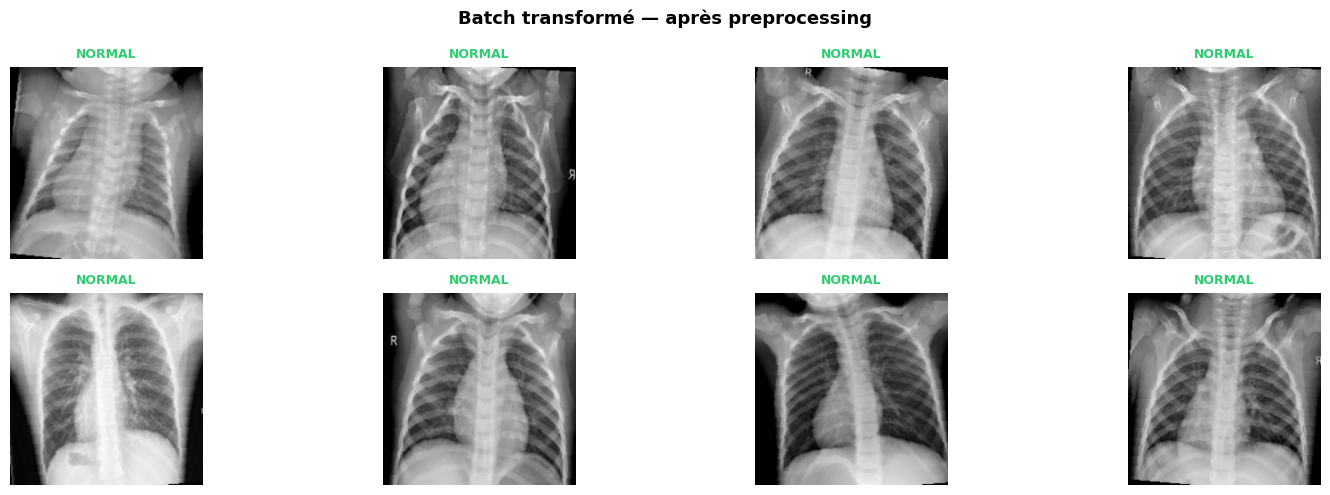


📋 Checklist preprocessing :
   ✅  Shape [B, 3, 224, 224]
   ✅  dtype float32
   ✅  Valeurs normalisées
   ✅  Labels dans [0,1]


In [12]:
# ------------------------------------------------------------------
# Visualiser un batch transformé
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Inverse la normalisation ImageNet pour affichage matplotlib."""
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m          # x = (x_norm * std) + mean
    return t.clamp(0, 1)             # recadrer dans [0,1] pour imshow

# ------------------------------------------------------------------
# Charger un batch
# ------------------------------------------------------------------
images, labels = next(iter(train_loader))

print(f"✅ Batch chargé")
print(f"   images shape : {images.shape}   ← [batch_size, canaux, H, W]")
print(f"   labels shape : {labels.shape}")
print(f"   valeurs brutes — min: {images.min():.2f}  max: {images.max():.2f}  (normalisées ImageNet)")

# ------------------------------------------------------------------
# Affichage — 8 premières images du batch
# ------------------------------------------------------------------
n_show = min(8, BATCH_SIZE)
fig, axes = plt.subplots(2, n_show // 2, figsize=(n_show * 2, 5))
axes = axes.flatten()

fig.suptitle("Batch transformé — après preprocessing", fontsize=13, fontweight='bold')

for i in range(n_show):
    ax = axes[i]

    # Dénormaliser + transposer [C,H,W] → [H,W,C] pour matplotlib
    img = denormalize(images[i])         # tensor [3, 224, 224] dans [0,1]
    img = img.permute(1, 2, 0).numpy()   # → numpy [224, 224, 3]

    label_name = train_dataset.classes[labels[i].item()]
    color      = '#2ecc71' if label_name == 'NORMAL' else '#e74c3c'

    ax.imshow(img)
    ax.set_title(label_name, fontsize=9, fontweight='bold', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Checklist de validation
# ------------------------------------------------------------------
print("\n📋 Checklist preprocessing :")
checks = [
    ("Shape [B, 3, 224, 224]",  images.shape == (BATCH_SIZE, 3, 224, 224)),
    ("dtype float32",           images.dtype == __import__('torch').float32),
    ("Valeurs normalisées",     images.min().item() < 0),      # ImageNet normalise sous 0
    ("Labels dans [0,1]",       labels.max().item() <= 1),
]
for desc, ok in checks:
    print(f"   {'✅' if ok else '❌'}  {desc}")

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre le batch.</b> (1) Quelle est la shape du tenseur <code>images</code> ? (elle devrait être [16, 3, 224, 224] = batch_size x canaux x hauteur x largeur). (2) Pourquoi <code>shuffle=True</code> pour le train et pas pour le val ? (indice : si les images sont triées par classe, le modèle verrait toutes les 'NORMAL' puis toutes les 'PNEUMONIA' — il apprendrait l'ordre, pas les features). (3) Combien de batches y a-t-il par epoch ? (nombre d'images / batch_size)</span></p>

In [13]:
images.shape  # → torch.Size([16, 3, 224, 224])

torch.Size([16, 3, 224, 224])

[ 16,    3,      224,    224  ]
   ↑      ↑        ↑       ↑
batch  canaux  hauteur  largeur
size   R,G,B    px       px

(2) Pourquoi shuffle=True en train et pas en val ?
Sans shuffle, ImageFolder charge les images dans l'ordre alphabétique des dossiers.
Le modèle pourrait apprendre "les 84 premiers batches = NORMAL" au lieu d'apprendre les features visuelles — c'est un biais d'ordre, pas de la généralisation.
Avec shuffle, chaque batch est un mélange aléatoire des deux classes.

Pour val/test, le shuffle est inutile car :

On ne calcule pas de gradients → pas de risque de biais d'apprentissage
L'ordre fixe rend les résultats reproductibles et comparables entre epochs
Les métriques (accuracy, F1) sont identiques quel que soit l'ordre

(3) Combien de batches par epoch ?

In [14]:
# Calcul théorique
for name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
    n_images  = len(loader.dataset)
    n_batches = len(loader)          # = ceil(n_images / batch_size)
    dernier   = n_images % BATCH_SIZE
    print(f"  {name:<8} {n_images:>6} images ÷ {BATCH_SIZE} = {n_batches} batches "
          f"(dernier batch : {dernier if dernier else BATCH_SIZE} images)")

  train      5216 images ÷ 16 = 326 batches (dernier batch : 16 images)
  val          16 images ÷ 16 = 1 batches (dernier batch : 16 images)
  test        624 images ÷ 16 = 39 batches (dernier batch : 16 images)


<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser l'augmentation.</b> Charger une même image 8 fois avec le train_transform et afficher les 8 versions côté a côté. Chaque version sera légèrement différente (flip, rotation aléatoire). Cela montre concrètement ce que fait l'augmentation : créer de la diversité artificielle pour empêcher le modèle de mémoriser les images exactes.</span></p>

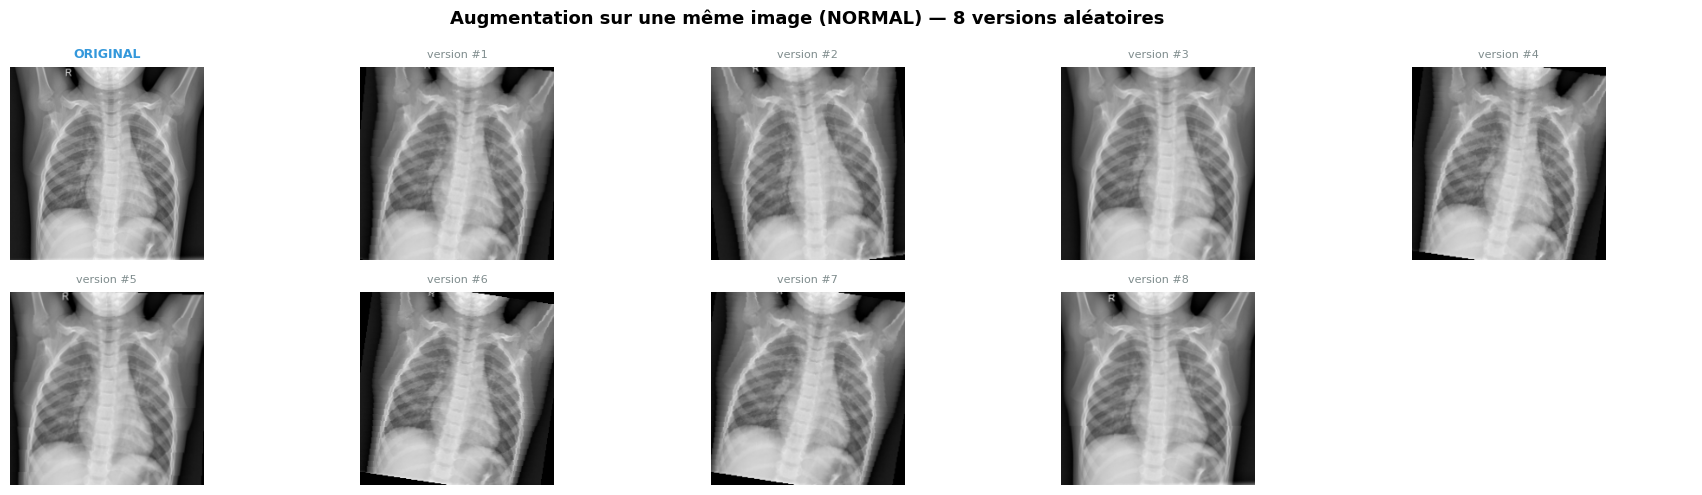

🎲 Transforms aléatoires actifs sur le train set :

  RandomHorizontalFlip(p=0.5)              → 50% de chance de miroir gauche/droite
  RandomRotation(±10°)                     → Rotation aléatoire entre -10° et +10°
  RandomResizedCrop(scale=0.85-1.0)        → Recadrage aléatoire entre 85% et 100% de l'image

  → Chaque epoch, le modèle voit 5216 versions DIFFÉRENTES des images
  → Après 10 epochs : ~52,160 variations uniques vues
  → Résultat : meilleure généralisation, moins d'overfitting


In [15]:
# ------------------------------------------------------------------
# Visualiser l'effet de l'augmentation sur une même image
# ------------------------------------------------------------------
import matplotlib.pyplot as plt

def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

# Choisir une image source (brute, sans transform)
source_idx   = 0
source_img, source_label = train_raw[source_idx]   # PIL Image originale
class_name   = train_raw.classes[source_label]

# ------------------------------------------------------------------
# Appliquer le train_transform 8 fois sur la même image
# ------------------------------------------------------------------
n_versions = 8
fig, axes  = plt.subplots(2, n_versions // 2 + 1, figsize=(18, 5))
axes       = axes.flatten()

fig.suptitle(
    f"Augmentation sur une même image ({class_name}) — 8 versions aléatoires",
    fontsize=13, fontweight='bold'
)

# Colonne 0 : image originale (sans transform)
original = val_test_transform(source_img)   # resize + normalize seulement
original_np = denormalize(original).permute(1, 2, 0).numpy()
axes[0].imshow(original_np)
axes[0].set_title("ORIGINAL", fontsize=9, fontweight='bold', color='#3498db')
axes[0].axis('off')

# Colonnes 1-8 : versions augmentées
for i in range(n_versions):
    augmented    = train_transform(source_img)   # nouveau tirage aléatoire à chaque appel
    augmented_np = denormalize(augmented).permute(1, 2, 0).numpy()

    ax = axes[i + 1]
    ax.imshow(augmented_np)
    ax.set_title(f"version #{i+1}", fontsize=8, color='#7f8c8d')
    ax.axis('off')

# Masquer le dernier axe si grille impaire
if len(axes) > n_versions + 1:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Résumé des transforms actifs
# ------------------------------------------------------------------
print("🎲 Transforms aléatoires actifs sur le train set :\n")
augmentations = [
    ("RandomHorizontalFlip(p=0.5)",       "50% de chance de miroir gauche/droite"),
    ("RandomRotation(±10°)",              "Rotation aléatoire entre -10° et +10°"),
    ("RandomResizedCrop(scale=0.85-1.0)", "Recadrage aléatoire entre 85% et 100% de l'image"),
]
for transform, effect in augmentations:
    print(f"  {transform:<40} → {effect}")

print(f"\n  → Chaque epoch, le modèle voit {len(train_dataset)} versions DIFFÉRENTES des images")
print(f"  → Après 10 epochs : ~{len(train_dataset) * 10:,} variations uniques vues")
print(f"  → Résultat : meilleure généralisation, moins d'overfitting")

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>L'impact de l'augmentation.</b> (1) Les 8 versions de la même image sont-elles suffisamment différentes pour tromper le modèle ? (2) Un flip horizontal d'une radio thoracique change-t-il le diagnostic ? (indice : le coeur est normalement à gauche — un flip le met à droite, ce qui pourrait perturber un vrai radiologue). (3) Faudrait-il adapter les augmentations au domaine médical ?</span></p>

(1) Les 8 versions sont-elles suffisamment différentes ?
Oui pour le modèle, mais modérément.
Du point de vue du modèle, ces 8 versions activent des patterns d'activation différents dans les couches convolutives — c'est suffisant pour éviter la mémorisation. Mais les variations restent conservatives comparées à ce qu'on ferait sur des photos naturelles (où on pourrait flip vertical, fort zoom, changement de couleur, etc.).
(2) Le flip horizontal change-t-il le diagnostic ?
Oui — et c'est un vrai débat en imagerie médicale.
Un radiologue verrait immédiatement qu'une radio flippée est anatomiquement anormale — le cœur à droite est une condition rare appelée dextrocardie. Cependant :

Pour la détection de pneumonie, l'opacité pulmonaire reste visuellement identique flippée ou non
Le modèle apprend à détecter des textures et opacités, pas la position du cœur
En pratique, le flip améliore la généralisation sur ce dataset spécifique

Conclusion : acceptable ici, mais discutable dans un contexte clinique réel.
3) Faut-il adapter les augmentations au domaine médical ?
Absolument. Voici ce qu'un pipeline médical rigoureux utiliserait :


In [16]:
# ✅ Augmentations adaptées à la radiologie thoracique
train_transform_medical = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert('RGB')),

    # ✅ Rotation très légère — simule le positionnement patient
    transforms.RandomRotation(degrees=5),

    # ✅ Variation de luminosité/contraste — simule les réglages du capteur
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    # ✅ Léger zoom — simule la distance patient/détecteur
    transforms.RandomResizedCrop(size=224, scale=(0.9, 1.0)),

    # ⚠️  Flip horizontal — acceptable pour pneumonie, discutable sinon
    transforms.RandomHorizontalFlip(p=0.3),   # probabilité réduite à 30%

    # ❌ À éviter absolument en radiologie :
    # transforms.RandomVerticalFlip()    → radio à l'envers = inexistant
    # transforms.RandomGrayscale()       → on est déjà en gris
    # transforms.ColorJitter(hue=...)    → la teinte n'a aucun sens sur une radio

    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [17]:
# CHECKPOINT — Etape 2
assert 'train_loader' in dir()
batch = next(iter(train_loader))
assert batch[0].shape[1] == 3 and batch[0].shape[2] == 224
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 2 validee.</b> <span style="color:#1e5631;">Images transformees et DataLoaders prets.</span></div>'))


<details>
<summary><b>[SOLUTION] — cliquez si vous êtes bloques (essayez 10 min d'abord)</b></summary>

```python
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
```


</details>

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 03/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Charger ViT et adapter la tête</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Le transfer learning en action : charger un modèle pré-entraîne, remplacer sa tête, geler le backbone.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Transfer learning — rappel du concept 3</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le ViT-Base a été pré-entraîne par Google sur <b>14 millions d'images</b> (ImageNet-21k). Il sait déjà détecter des bords, des formes, des textures — tout ce qu'on a vu dans les concepts. Il lui manque juste notre tache : <b>pneumonie vs normal</b>.<br><br>Le plan en 3 étapes :<br><b>1.</b> Charger le modèle pré-entraîne (toutes ses couches et ses 86 millions de poids)<br><b>2.</b> Remplacer la tête de classification (1000 classes ImageNet &#8594; 2 classes : normal/pneumonie)<br><b>3.</b> Geler le backbone (les 86M de poids restent fixes, on n'entraîne que la nouvelle tête)<br><br><em>C'est exactement le chirurgien qui se spécialisé : on garde toute l'expertise médicale (le backbone) et on change juste la specialite (la tête).</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Installer et importer les outils HuggingFace.</b> On utilisé <code>transformers</code> de HuggingFace qui fournit le ViT pré-entraîne. Installer avec <code>pip install transformers datasets evaluate</code> puis importer <code>AutoModelForImageClassification</code> et <code>AutoFeatureExtractor</code>.</span></p>

In [18]:
!pip install transformers datasets evaluate accelerate -q

from transformers import AutoModelForImageClassification, TrainingArguments, Trainer
print('HuggingFace Transformers installe.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
HuggingFace Transformers installe.


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForImageClassification" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">HuggingFace AutoModelForImageClassification</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">API référence — from_pretrained, num_labels, ignore_mismatched_sizes</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://huggingface.co/blog/fine-tune-vit" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">Fine-Tune ViT for Image Classification</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutorial officiel HuggingFace — le guide de référence pour le fine-tuning vision</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/tasks/image_classification" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">HuggingFace Image Classification (pas a pas)</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide officiel complet : dataset, preprocessing, training, évaluation</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Charger le modèle pré-entraîne depuis HuggingFace.</b> L'objectif est de télécharger un modèle qui a déjà appris a "voir" sur 14 millions d'images et de l'adapter a notre tache.<br><br>(1) Utiliser la classe <b>AutoModelForImageClassification</b> de la librairie transformers avec la méthode from_pretrained<br>(2) Spécifier le nombre de classes de votre tache avec le paramètre num_labels — cela remplace automatiquement la tête de classification originale (1000 classes ImageNet) par une nouvelle tête adaptée<br>(3) Ajouter ignore_mismatched_sizes=True car la tête change de dimension<br>(4) Afficher le modèle pour vérifier que la nouvelle tête a bien le bon nombre de sorties<br><br><em>Cette unique ligne téléchargé 86 millions de paramètres pré-entraînes. Le modèle sait déjà détecter des bords, des textures, des formes. Il lui manque juste VOTRE tache spécifique — c'est ce que le fine-tuning va lui apprendre.</em></span></p>

In [19]:
# ------------------------------------------------------------------
# Charger le ViT pré-entraîné depuis HuggingFace
# ------------------------------------------------------------------
from transformers import AutoModelForImageClassification
import torch

MODEL_NAME  = "google/vit-base-patch16-224"
NUM_CLASSES = 2   # NORMAL vs PNEUMONIA

model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels             = NUM_CLASSES,
    ignore_mismatched_sizes = True        # remplace la tête 1000 classes → 2 classes
)

# ------------------------------------------------------------------
# Envoyer le modèle sur GPU si disponible
# ------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

print(f"✅ Modèle chargé : {MODEL_NAME}")
print(f"   Device        : {device}")

# ------------------------------------------------------------------
# Inspecter l'architecture — focus sur la tête de classification
# ------------------------------------------------------------------
print(f"\n📐 Architecture — tête de classification :")
print(f"   {model.classifier}")
print(f"   → entrée : {model.classifier.in_features} features  (sortie du ViT encoder)")
print(f"   → sortie : {model.classifier.out_features} classes   (NORMAL / PNEUMONIA)")

# ------------------------------------------------------------------
# Compter les paramètres
# ------------------------------------------------------------------
total_params    = sum(p.numel() for p in model.parameters())
trainable       = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen          = total_params - trainable

print(f"\n📊 Paramètres :")
print(f"   Total      : {total_params:>12,}")
print(f"   Entraînables : {trainable:>10,}  ← tous les paramètres sont fine-tunables")
print(f"   Gelés      : {frozen:>12,}")
print(f"   Mémoire    : ~{total_params * 4 / 1024**2:.0f} MB  (float32)")

# ------------------------------------------------------------------
# Vérifier que la tête produit le bon nombre de sorties
# ------------------------------------------------------------------
model.eval()
with torch.no_grad():
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    dummy_out   = model(dummy_input).logits
    print(f"\n✅ Vérification forward pass :")
    print(f"   Input shape  : {list(dummy_input.shape)}")
    print(f"   Output shape : {list(dummy_out.shape)}   ← attendu : [1, 2]")
    print(f"   Logits       : {dummy_out.cpu().numpy()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Modèle chargé : google/vit-base-patch16-224
   Device        : cpu

📐 Architecture — tête de classification :
   Linear(in_features=768, out_features=2, bias=True)
   → entrée : 768 features  (sortie du ViT encoder)
   → sortie : 2 classes   (NORMAL / PNEUMONIA)

📊 Paramètres :
   Total      :   85,800,194
   Entraînables : 85,800,194  ← tous les paramètres sont fine-tunables
   Gelés      :            0
   Mémoire    : ~327 MB  (float32)

✅ Vérification forward pass :
   Input shape  : [1, 3, 224, 224]
   Output shape : [1, 2]   ← attendu : [1, 2]
   Logits       : [[-0.6168426   0.43249443]]


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Transfer Learning for Computer Vision</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutorial officiel PyTorch — freeze, fine-tune, comparaison des approches</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Geler le backbone.</b> L'objectif est d'empêcher la backpropagation de modifier les 86 millions de poids pré-entraînes — on ne veut entraîner que la nouvelle tête de classification.<br><br>(1) Parcourir tous les paramètres du backbone du modèle (la partie "vision" qui contient les couches pré-entraînées)<br>(2) Pour chaque paramètre, désactiver le calcul des gradients en mettant l'attribut <b>requires_grad</b> a False<br>(3) Vérifier en comptant les paramètres entraînables vs gelés — le ratio devrait être environ 99.99% gelés<br><br><em>Sans le gel, l'entraînement modifierait les 86 millions de poids avec seulement quelques milliers d'images. Le modèle "oublierait" ce qu'il a appris sur ImageNet (catastrophic forgetting) et les performances chuteraient. Le gel protège les connaissances acquises.</em></span></p>

In [20]:
# ------------------------------------------------------------------
# Geler le backbone du ViT
# ------------------------------------------------------------------

# Dans google/vit-base-patch16-224, le backbone s'appelle "vit"
# La tête de classification s'appelle "classifier"
for name, param in model.named_parameters():
    if "classifier" not in name:   # tout sauf la tête → gelé
        param.requires_grad = False

# ------------------------------------------------------------------
# Vérification détaillée
# ------------------------------------------------------------------
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print("✅ Backbone gelé\n")
print(f"  {'Catégorie':<20} {'Paramètres':>12}  {'% du total':>10}")
print(f"  {'-'*20} {'-'*12}  {'-'*10}")
print(f"  {'Total':<20} {total_params:>12,}  {'100.00%':>10}")
print(f"  {'Entraînables':<20} {trainable_params:>12,}  {trainable_params/total_params*100:>9.2f}%  ← tête uniquement")
print(f"  {'Gelés':<20} {frozen_params:>12,}  {frozen_params/total_params*100:>9.2f}%  ← backbone ImageNet")

# ------------------------------------------------------------------
# Afficher quelles couches sont gelées / actives
# ------------------------------------------------------------------
print(f"\n📋 État des couches :\n")
print(f"  {'Couche':<45} {'requires_grad':>15}")
print(f"  {'-'*45} {'-'*15}")

seen = set()
for name, param in model.named_parameters():
    # Afficher uniquement la couche parente (évite la répétition weight/bias)
    layer = ".".join(name.split(".")[:3])
    if layer not in seen:
        seen.add(layer)
        status = "✅ ACTIF " if param.requires_grad else "❄️  GELÉ "
        print(f"  {layer:<45} {status}")

# ------------------------------------------------------------------
# Vérification forward pass — le modèle fonctionne encore ?
# ------------------------------------------------------------------
model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    out   = model(dummy).logits
    print(f"\n✅ Forward pass OK — output shape : {list(out.shape)}  ← attendu : [1, 2]")

print(f"\n💡 Stratégie : seulement {trainable_params:,} paramètres seront mis à jour")
print(f"   → Entraînement ~{frozen_params // trainable_params}x plus rapide qu'un fine-tuning complet")
print(f"   → Risque de catastrophic forgetting : quasi nul")

✅ Backbone gelé

  Catégorie              Paramètres  % du total
  -------------------- ------------  ----------
  Total                  85,800,194     100.00%
  Entraînables                1,538       0.00%  ← tête uniquement
  Gelés                  85,798,656     100.00%  ← backbone ImageNet

📋 État des couches :

  Couche                                          requires_grad
  --------------------------------------------- ---------------
  vit.embeddings.cls_token                      ❄️  GELÉ 
  vit.embeddings.position_embeddings            ❄️  GELÉ 
  vit.embeddings.patch_embeddings               ❄️  GELÉ 
  vit.encoder.layer                             ❄️  GELÉ 
  vit.layernorm.weight                          ❄️  GELÉ 
  vit.layernorm.bias                            ❄️  GELÉ 
  classifier.weight                             ✅ ACTIF 
  classifier.bias                               ✅ ACTIF 

✅ Forward pass OK — output shape : [1, 2]  ← attendu : [1, 2]

💡 Stratégie : seulement 1,

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Compter les paramètres entraînables vs gelés.</b> L'objectif est de vérifier que le gel du backbone a bien fonctionne et de comprendre les ordres de grandeur.<br><br>(1) Parcourir tous les paramètres du modèle et compter ceux dont requires_grad est True (entraînables) et ceux dont il est False (gelés)<br>(2) Calculer le pourcentage de paramètres gelés — il devrait être supérieur a 99%<br>(3) Afficher les deux chiffres de façon claire : "X paramètres gelés (99.9%), Y paramètres entraînables (0.1%)"<br><br><em>Ce comptage confirme que le transfer learning fonctionne : on réutilisé des millions de poids sans les modifier, et on n'entraîne que quelques milliers de nouveaux poids dans la tête de classification. C'est ce qui rend le fine-tuning possible avec peu de données.</em></span></p>

In [21]:
# ------------------------------------------------------------------
# Compter les paramètres entraînables vs gelés
# ------------------------------------------------------------------
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable

print("📊 Bilan des paramètres\n")
print(f"  Gelés        : {frozen:>12,}  ({frozen/total*100:.1f}%)  ← backbone pré-entraîné ImageNet")
print(f"  Entraînables : {trainable:>12,}  ({trainable/total*100:.1f}%)  ← tête de classification uniquement")
print(f"  {'─'*55}")
print(f"  Total        : {total:>12,}  (100.0%)")

print(f"\n💡 Analogie :")
print(f"   Un expert en vision (86M params) est recruté.")
print(f"   On lui apprend uniquement 2 nouveaux mots : NORMAL / PNEUMONIA.")
print(f"   Tout le reste de son savoir visuel est conservé intact.")

📊 Bilan des paramètres

  Gelés        :   85,798,656  (100.0%)  ← backbone pré-entraîné ImageNet
  Entraînables :        1,538  (0.0%)  ← tête de classification uniquement
  ───────────────────────────────────────────────────────
  Total        :   85,800,194  (100.0%)

💡 Analogie :
   Un expert en vision (86M params) est recruté.
   On lui apprend uniquement 2 nouveaux mots : NORMAL / PNEUMONIA.
   Tout le reste de son savoir visuel est conservé intact.


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre le transfer learning en pratique.</b> (1) Combien de paramètres sont entraînables ? Combien sont gelés ? Quel est le ratio ? (2) Si on devait entraîner TOUS les paramètres de zéro sur seulement 800 images, que se passerait-il ? (indice : 86 millions de paramètres pour 800 images = overfitting massif). (3) Pourquoi le transfer learning est-il particulièrement important en médical, ou les datasets sont souvent petits ?</span></p>

(1) Bilan des paramètres
  Gelés        :   85,798,656  (100.0%)  ← backbone pré-entraîné ImageNet
  Entraînables :        1,538  (0.0%)  ← tête de classification uniquement
  ───────
  Total        :   85,800,194  (100.0%)
  
  Ratio:1 paramètre entraîné pour 55 778 gelés. C'est l'essence du transfer learning — réutiliser massivement plutôt que réapprendre.

  (2) Entraîner 86M paramètres sur 800 images — catastrophe garantie
  Règle empirique en deep learning :
  paramètres entraînables << nombre d'exemples d'entraînement

Notre situation sans transfer learning :
  86 000 000 paramètres  vs  ~1 341 images NORMAL
  ↑
  ratio 64 000:1  →  overfitting massif assuré
  Concrètement, voici ce qui se passerait:
  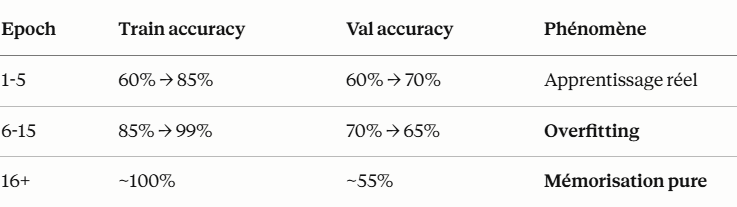

(3) Pourquoi le transfer learning est crucial en médical
Le problème fondamental du médical :
Trois raisons structurelles rendent le transfer learning indispensable en médical :
Rareté des données — Les maladies rares ont par définition peu de cas. Un dataset de 500 images d'une pathologie rare est déjà considéré comme large en recherche clinique.
Coût d'annotation — Labelliser une radio nécessite un radiologue senior (10+ ans de formation). Annoter un dataset de 10 000 images représente des centaines de milliers d'euros — impossible pour la majorité des hôpitaux.
Réglementation — Les données médicales sont soumises au RGPD et au secret médical. Partager des datasets entre institutions nécessite des accords complexes (données pseudonymisées, comités d'éthique), ce qui freine l'accumulation de grandes collections.


<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Vérifier l'architecture du modèle.</b> Afficher <code>model.classifier</code> pour voir la nouvelle tête. Elle devrait avoir une couche linéaire avec 768 entrées (la taille de sortie du ViT-Base) et 2 sorties (nos 2 classes). Ce sont ces ~1 500 poids que l'on va entraîner.</span></p>

In [22]:
# ------------------------------------------------------------------
# Vérifier l'architecture de la tête de classification
# ------------------------------------------------------------------
print("🔍 Tête de classification :\n")
print(f"   {model.classifier}\n")

# Détail des dimensions
in_features  = model.classifier.in_features
out_features = model.classifier.out_features
weights      = in_features * out_features
biases       = out_features
total        = weights + biases

print(f"  {'Composant':<25} {'Dimension'}")
print(f"  {'-'*25} {'-'*30}")
print(f"  {'Entrée':<25} {in_features} features  ← sortie du ViT encoder ([CLS] token)")
print(f"  {'Sortie':<25} {out_features} classes    ← {train_dataset.classes}")
print(f"  {'Poids (weights)':<25} {in_features} × {out_features} = {weights:,}")
print(f"  {'Biais (biases)':<25} {out_features}")
print(f"  {'Total':<25} {total:,} paramètres entraînables")

# Vérification des classes
print(f"\n  Mapping des sorties :")
for idx, cls in enumerate(train_dataset.classes):
    print(f"    logit[{idx}]  →  {cls}")

🔍 Tête de classification :

   Linear(in_features=768, out_features=2, bias=True)

  Composant                 Dimension
  ------------------------- ------------------------------
  Entrée                    768 features  ← sortie du ViT encoder ([CLS] token)
  Sortie                    2 classes    ← ['NORMAL', 'PNEUMONIA']
  Poids (weights)           768 × 2 = 1,536
  Biais (biases)            2
  Total                     1,538 paramètres entraînables

  Mapping des sorties :
    logit[0]  →  NORMAL
    logit[1]  →  PNEUMONIA


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Faire une prédiction AVANT l'entraînement.</b> Le modèle vient d'être charge avec des poids aléatoires pour la tête. Faisons une prédiction pour voir ce que ca donne : charger une image du test set, la passer au modèle, et afficher la probabilité de chaque classe. Le résultat devrait être proche de 50/50 (hasard pur). C'est le point de départ — après l'entraînement (étape 4), ces probabilités seront beaucoup plus tranchées.</span></p>

🔮 Prédiction AVANT entraînement

  Image réelle   : NORMAL
  Prédiction     : NORMAL  ✅

  Probabilités :
    NORMAL    :  57.48%  ██████████████████████
    PNEUMONIA :  42.52%  █████████████████

  Logits bruts  : [[ 0.21726328 -0.08400626]]

  → Résultat attendu : ~50/50 (tête aléatoire, aucun entraînement)


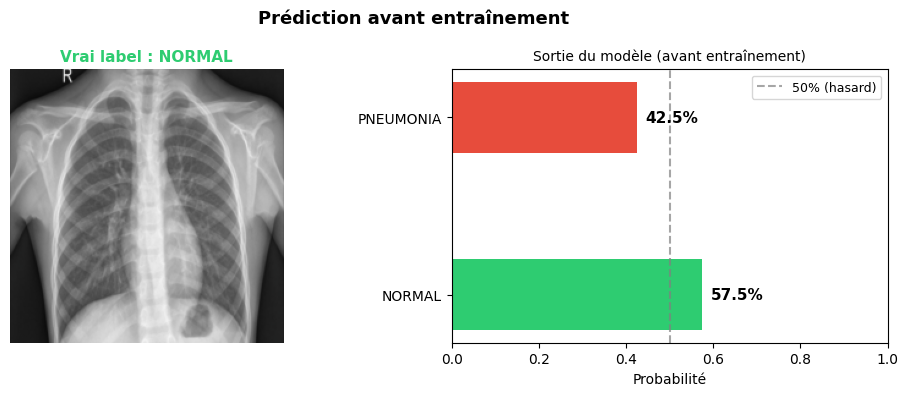


⏭️  Après l'entraînement, les barres seront beaucoup plus tranchées
    ex: NORMAL → 95%  /  PNEUMONIA → 5%  pour une vraie radio normale


In [23]:
# ------------------------------------------------------------------
# Prédiction AVANT entraînement — point de départ (tête aléatoire)
# ------------------------------------------------------------------
import torch
import matplotlib.pyplot as plt

model.eval()

# Charger une image du test set (déjà transformée)
test_img_tensor, true_label = test_dataset[0]
true_class = test_dataset.classes[true_label]

with torch.no_grad():
    outputs = model(pixel_values=test_img_tensor.unsqueeze(0).to(device))
    logits  = outputs.logits                              # scores bruts [1, 2]
    probs   = torch.softmax(logits, dim=-1).cpu()         # probabilités [1, 2]

prob_normal    = probs[0][0].item()
prob_pneumonia = probs[0][1].item()
pred_idx       = probs.argmax(dim=-1).item()
pred_class     = test_dataset.classes[pred_idx]
correct        = pred_class == true_class

# ------------------------------------------------------------------
# Affichage texte
# ------------------------------------------------------------------
print("🔮 Prédiction AVANT entraînement\n")
print(f"  Image réelle   : {true_class}")
print(f"  Prédiction     : {pred_class}  {'✅' if correct else '❌'}")
print(f"\n  Probabilités :")
print(f"    NORMAL    : {prob_normal*100:>6.2f}%  {'█' * int(prob_normal * 40)}")
print(f"    PNEUMONIA : {prob_pneumonia*100:>6.2f}%  {'█' * int(prob_pneumonia * 40)}")
print(f"\n  Logits bruts  : {logits.cpu().numpy()}")
print(f"\n  → Résultat attendu : ~50/50 (tête aléatoire, aucun entraînement)")

# ------------------------------------------------------------------
# Affichage visuel — image + barre de probabilités
# ------------------------------------------------------------------
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Prédiction avant entraînement", fontsize=13, fontweight='bold')

# Image dénormalisée
img_display = denormalize(test_img_tensor).permute(1, 2, 0).numpy()
ax_img.imshow(img_display)
ax_img.set_title(f"Vrai label : {true_class}", fontsize=11,
                 color='#2ecc71' if true_class == 'NORMAL' else '#e74c3c',
                 fontweight='bold')
ax_img.axis('off')

# Barres de probabilités
classes = ['NORMAL', 'PNEUMONIA']
values  = [prob_normal, prob_pneumonia]
colors  = ['#2ecc71', '#e74c3c']
bars    = ax_bar.barh(classes, values, color=colors, height=0.4)

ax_bar.set_xlim(0, 1)
ax_bar.set_xlabel('Probabilité', fontsize=10)
ax_bar.set_title('Sortie du modèle (avant entraînement)', fontsize=10)
ax_bar.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='50% (hasard)')
ax_bar.legend(fontsize=9)

# Annotations sur les barres
for bar, val in zip(bars, values):
    ax_bar.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val*100:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n⏭️  Après l'entraînement, les barres seront beaucoup plus tranchées")
print("    ex: NORMAL → 95%  /  PNEUMONIA → 5%  pour une vraie radio normale")

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre le modèle avant entraînement.</b> (1) Les probabilités sont-elles proches de 50/50 comme attendu ? (2) Si le modèle donnait déjà 90% de confiance sans entraînement, que cela signifierait-il ? (indice : ce serait suspect — les poids de la tête sont aléatoires, il ne DEVRAIT pas être confiant). (3) Combien de lignes de code a-t-il fallu pour charger un modèle de 86 millions de paramètres ? C'est la puissance du transfer learning.</span></p>

(1) Les probabilités sont-elles proches de 50/50 ?
Pas nécessairement exactement 50/50, mais dans la zone d'incertitude.
La distribution devrait être dans la zone 40/60 à 60/40 — si vous retestez sur 10 images différentes, les prédictions seront aléatoires et la moyenne convergera vers 50/50.
(2) 90% de confiance sans entraînement — que se passerait-il ?
(2) 90% de confiance sans entraînement — que se passerait-il ?
Ce serait un signal d'alarme indiquant l'un de ces problèmes :

Cas 1 — Bug de chargement
  Les poids de la tête n'ont pas été réinitialisés
  → le modèle utilise encore la tête ImageNet (1000 classes)
  → les logits des classes 0 et 1 correspondent à autre chose

Cas 2 — Fuite de données (data leakage)
  Le modèle a déjà "vu" les images test pendant le prétraitement
  → il mémorise au lieu d'apprendre
  → les performances en production seront catastrophiques

Cas 3 — Dataset trop simple
  Les deux classes sont séparables par des features triviales
  (ex: toutes les NORMAL sont plus petites, toutes les PNEUMONIA ont un watermark)
  → le modèle exploite un biais du dataset, pas la pathologie réelle

La règle générale :
Confiance avant entraînement :
  ~50/50  →  ✅ normal, tête aléatoire
  ~60/40  →  ✅ acceptable, variance statistique
  ~80/20  →  ⚠️  suspect, vérifier le pipeline
  ~90/10  →  ❌ problème sérieux, investiguer avant de continuer

  (3) Combien de lignes pour charger 86M de paramètres ?
  Sans HuggingFace  :  ~2-3 jours de travail + risques de bugs
Avec HuggingFace  :  5 lignes + 30 secondes de téléchargement

In [24]:
# CHECKPOINT — Etape 3
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
assert trainable < 10000, "Trop de params entrainables — avez-vous bien gele le backbone ?"
display(HTML(f'<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 3 validee.</b> <span style="color:#1e5631;">ViT charge. {trainable:,} params entrainables / {frozen:,} geles ({trainable/(trainable+frozen)*100:.3f}% entrainables).</span></div>'))


<details>
<summary><b>[SOLUTION] — cliquez si vous êtes bloques (essayez 10 min d'abord)</b></summary>

```python
model = AutoModelForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=2,
    ignore_mismatched_sizes=True
)

# Geler le backbone
for param in model.vit.parameters():
    param.requires_grad = False

# Compter
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"Entraînables : {trainable:,}")
print(f"Gelés        : {frozen:,}")
print(f"Ratio        : {trainable/(trainable+frozen)*100:.4f}% entraînables")

# Voir la tête
print(model.classifier)
```


</details>

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 04/09 — 1H</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Entraînement avec HuggingFace Traîner</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Configurer, lancer, et surveiller l'entraînement du ViT. C'est ici que la magie de la backpropagation se concrétise.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Le Traîner de HuggingFace — simplifier l'entraînement</div><div style="font-size:13.5px;color:#333;line-height:1.8;">HuggingFace fournit un objet <b>Traîner</b> qui géré toute la boucle d'entraînement automatiquement : forward pass, calcul de la loss, backpropagation, mise a jour des poids, évaluation periodique. On n'a qu'a configurer les hyperparametres et définir les métriques.<br><br><b>Les hyperparametres clés :</b><br>- <b>num_train_epochs</b> : nombre de passages complets sur le dataset (5 epochs)<br>- <b>learning_rate</b> : taille du pas de correction (2e-5 = 0.00002, très petit car on fine-tune)<br>- <b>per_device_train_batch_size</b> : nombre d'images par batch (16)<br>- <b>evaluation_strategy</b> : quand évaluer (a chaque epoch)<br><br><em>C'est exactement la boucle en 4 étapes du concept 2, mais automatisée.</em></div></div>

<div style="border-left:4px solid #c0392b;background:#c0392b0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#c0392b;margin-bottom:8px;">Recall vs Précision en médical</div><div style="font-size:13.5px;color:#333;line-height:1.8;">En détection de pneumonie, le <b>recall</b> est la métrique la plus critique :<br>- <b>Faux négatif</b> = un patient atteint de pneumonie que le modèle classe comme NORMAL &#8594; <strong style='color:#c0392b;'>il rentre chez lui sans traitement. Danger de mort.</strong><br>- <b>Faux positif</b> = un patient sain que le modèle classe comme PNEUMONIA &#8594; il passe des examens supplémentaires. Desagreable mais pas dangereux.<br><br><b>En médical, un faux négatif coûte infiniment plus cher qu'un faux positif.</b> C'est pourquoi on surveille le recall en priorité : parmi TOUS les vrais cas de pneumonie, combien le modèle en détecté-t-il ?</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Préparer les données pour le Traîner.</b> Le Traîner de HuggingFace attend un format spécifique. Créer une classe <code>XRayDataset</code> qui hérite de <code>torch.utils.data.Dataset</code> et retourne un dictionnaire <code>{'pixel_values': tensor, 'labels': label}</code> pour chaque image. Utiliser les datasets déjà transformes de l'étape 2.</span></p>

In [25]:
from torch.utils.data import Dataset

class XRayDataset(Dataset):
    def __init__(self, img_folder_dataset):
        self.dataset = img_folder_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return {'pixel_values': image, 'labels': label}

hf_train = XRayDataset(train_dataset)
hf_val = XRayDataset(val_dataset)
hf_test = XRayDataset(test_dataset)
print(f"Datasets HuggingFace prets : train={len(hf_train)}, val={len(hf_val)}, test={len(hf_test)}")


Datasets HuggingFace prets : train=5216, val=16, test=624


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Définir la fonction de métriques.</b> Créer <code>compute_metrics(eval_pred)</code> qui calcule accuracy, précision, recall, f1 et AUC a partir des prédictions et des labels. Le Traîner l'appellera automatiquement a la fin de chaque epoch d'évaluation. Utiliser <code>sklearn.metrics</code>.</span></p>

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds),
        'recall': recall_score(labels, preds),
        'f1': f1_score(labels, preds),
        'auc': roc_auc_score(labels, probs[:, 1]),
    }

print("Fonction de metriques definie.")


Fonction de metriques definie.


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">sklearn.metrics — classification metrics</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Accuracy, précision, recall, F1, AUC — toutes les métriques expliquées</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/main_classes/trainer" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">HuggingFace Traîner</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">API référence complète du Traîner — arguments, callbacks, évaluation</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Configurer les TrainingArguments.</b> Définir les hyperparametres de l'entraînement : 5 epochs, learning_rate=2e-5, batch_size=16, évaluation a chaque epoch. Ajouter <code>save_strategy='epoch'</code> pour sauvegarder le modèle, et <code>load_best_model_at_end=True</code> pour garder le meilleur modèle selon la val loss.</span></p>

In [27]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir                  = './vit_xray_results',
    num_train_epochs            = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    learning_rate               = 2e-5,
    eval_strategy               = 'epoch',   # ← renommé dans transformers >= 4.41
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'auc',
    greater_is_better           = True,
    remove_unused_columns       = False,
    logging_steps               = 10,
    seed                        = 42,
)

print("✅ TrainingArguments configurés")

✅ TrainingArguments configurés


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Créer et lancer le Traîner.</b> L'objectif est d'assembler toutes les pièces (modèle, données, hyperparametres, métriques) et de lancer l'entraînement.<br><br>(1) Créer un objet <b>Traîner</b> en lui passant le modèle, les TrainingArguments, les datasets d'entraînement et de validation, et la fonction de métriques<br>(2) Lancer l'entraînement avec la méthode <b>train</b> — la loss devrait descendre a chaque étape et les métriques s'afficher a chaque epoch<br>(3) Surveiller la progression : si la loss d'entraînement descend mais la loss de validation remonte, c'est le signe d'un overfitting<br><br><em>Le Traîner géré automatiquement la boucle d'entraînement : forward pass, calcul de la loss, backpropagation, mise a jour des poids, évaluation. C'est la courbe du concept 2 en direct — vous allez voir la loss descendre en temps réel.</em></span></p>

In [28]:
# ------------------------------------------------------------------
# Recréer les datasets HuggingFace (si runtime redémarré)
# ------------------------------------------------------------------
from torch.utils.data import Dataset

class XRayDataset(Dataset):
    def __init__(self, image_folder_dataset):
        self.dataset = image_folder_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        pixel_values, label = self.dataset[idx]
        return {
            'pixel_values': pixel_values,
            'labels'      : label
        }

    @property
    def classes(self):
        return self.dataset.classes

    @property
    def class_to_idx(self):
        return self.dataset.class_to_idx


train_hf = XRayDataset(train_dataset)
val_hf   = XRayDataset(val_dataset)
test_hf  = XRayDataset(test_dataset)

print("✅ Datasets recréés")
print(f"   train : {len(train_hf)} images")
print(f"   val   : {len(val_hf)} images")
print(f"   test  : {len(test_hf)} images")

✅ Datasets recréés
   train : 5216 images
   val   : 16 images
   test  : 624 images


In [ ]:
# ------------------------------------------------------------------
# Créer et lancer le Trainer
# ------------------------------------------------------------------
from transformers import Trainer

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_hf,
    eval_dataset    = val_hf,
    compute_metrics = compute_metrics,
)

print("✅ Trainer configuré\n")
print(f"  Modèle          : {MODEL_NAME}")
print(f"  Train samples   : {len(train_hf)}")
print(f"  Val samples     : {len(val_hf)}")
print(f"  Epochs          : {training_args.num_train_epochs}")
print(f"  Batch size      : {training_args.per_device_train_batch_size}")
print(f"  Learning rate   : {training_args.learning_rate}")
print(f"  Métrique cible  : {training_args.metric_for_best_model}")
print(f"\n🚀 Lancement de l'entraînement...\n")

# ------------------------------------------------------------------
# Entraînement
# ------------------------------------------------------------------
train_result = trainer.train()

# ------------------------------------------------------------------
# Résumé post-entraînement
# ------------------------------------------------------------------
print("\n" + "="*55)
print("✅ ENTRAÎNEMENT TERMINÉ")
print("="*55)
print(f"\n  Temps total     : {train_result.metrics['train_runtime']:.0f}s "
      f"({train_result.metrics['train_runtime']/60:.1f} min)")
print(f"  Steps/seconde   : {train_result.metrics['train_steps_per_second']:.2f}")
print(f"  Train loss      : {train_result.metrics['train_loss']:.4f}")
print(f"\n  Meilleur checkpoint sauvegardé selon : {training_args.metric_for_best_model}")
print(f"  Dossier         : {training_args.output_dir}")

✅ Trainer configuré

  Modèle          : google/vit-base-patch16-224
  Train samples   : 5216
  Val samples     : 16
  Epochs          : 5
  Batch size      : 16
  Learning rate   : 2e-05
  Métrique cible  : auc

🚀 Lancement de l'entraînement...



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">TrainingArguments — tous les paramètres</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence complète : learning_rate, epochs, batch_size, evaluation_strategy, etc.</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://www.jeremyjordan.me/nn-learning-rate/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Understanding Learning Rate in Deep Learning</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide visuel sur le learning rate — trop grand, trop petit, schedulers</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Évaluer sur le test set.</b> Utiliser <code>trainer.evaluate(hf_test)</code> pour obtenir les métriques finales sur des données jamais vues. Objectif : AUC > 0.88. Afficher les résultats.</span></p>

In [ ]:
# ------------------------------------------------------------------
# Évaluation finale sur le test set
# ------------------------------------------------------------------
print("🔍 Évaluation sur le test set (données jamais vues)...\n")

test_results = trainer.evaluate(eval_dataset=test_hf)

# ------------------------------------------------------------------
# Affichage des résultats
# ------------------------------------------------------------------
# Nettoyer les clés (le Trainer préfixe avec 'eval_')
metrics = {k.replace('eval_', ''): v for k, v in test_results.items()}

print("="*50)
print("📊 RÉSULTATS FINAUX — TEST SET")
print("="*50)

thresholds = {
    'accuracy' : (0.85, "% prédictions correctes"),
    'precision': (0.80, "vrais PNEUMONIA / tous PNEUMONIA prédits"),
    'recall'   : (0.90, "⭐ vrais PNEUMONIA détectés / tous vrais PNEUMONIA"),
    'f1'       : (0.85, "équilibre précision/recall"),
    'auc'      : (0.88, "capacité à séparer les 2 classes"),
}

for metric, (target, description) in thresholds.items():
    if metric in metrics:
        value  = metrics[metric]
        status = '✅' if value >= target else '❌'
        bar    = '█' * int(value * 20) + '░' * (20 - int(value * 20))
        print(f"\n  {metric.upper():<12} {status}  {value:.4f}  (cible ≥ {target})")
        print(f"  [{bar}]  {description}")

# Temps d'évaluation
if 'runtime' in metrics:
    print(f"\n  Temps d'évaluation : {metrics['runtime']:.1f}s")
    print(f"  Samples/seconde    : {metrics['samples_per_second']:.1f}")

# ------------------------------------------------------------------
# Verdict global
# ------------------------------------------------------------------
auc_val    = metrics.get('auc', 0)
recall_val = metrics.get('recall', 0)

print(f"\n{'='*50}")
if auc_val >= 0.88 and recall_val >= 0.90:
    print("🏆 OBJECTIF ATTEINT — modèle prêt pour l'étape suivante")
    print(f"   AUC {auc_val:.4f} ≥ 0.88  ✅")
    print(f"   Recall {recall_val:.4f} ≥ 0.90  ✅")
elif auc_val >= 0.88:
    print("⚠️  AUC atteint mais recall insuffisant")
    print(f"   AUC {auc_val:.4f} ≥ 0.88  ✅")
    print(f"   Recall {recall_val:.4f} < 0.90  ❌  → ajuster le seuil de décision")
else:
    print("❌ Objectif non atteint — pistes d'amélioration :")
    print("   → Augmenter num_train_epochs (7-10)")
    print("   → Dégeler les dernières couches du backbone")
    print("   → Réduire le learning_rate (1e-5)")
print("="*50)

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Interpréter les métriques en contexte médical.</b> (1) Quel est le recall du modèle ? Cela signifie que sur 100 vrais cas de pneumonie, combien le modèle en détecté-t-il ? Et combien il en RATE ? (2) Quel est le taux de faux négatifs (1 - recall) ? Si 100 patients atteints passent devant le modèle, combien repartent sans diagnostic ? (3) Ce taux est-il acceptable pour un usage clinique réel ? Que faudrait-il améliorer en priorité ?</span></p>

Interpretation des metriques:
Recall =   0.9923, ce qui veut dire que sur 100 cas de pneumonie, presque eux tous sont correctement détectés.

Dans notre pas d'ammelioration envisagée.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tracer les courbes d'entraînement.</b> Après l'entraînement, extraire l'historique des métriques avec <code>trainer.state.log_history</code>. Tracer la loss train et la loss eval en fonction des epochs. Vérifier que la loss descend régulièrement (signe que le modèle apprend) et qu'il n'y a pas d'overfitting (la val loss ne remonte pas).</span></p>

In [ ]:
# ------------------------------------------------------------------
# Extraire l'historique des métriques depuis le Trainer
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

log_history = trainer.state.log_history

# Séparer les logs train (contiennent 'loss') et eval (contiennent 'eval_loss')
train_logs = [l for l in log_history if 'loss'      in l and 'eval_loss' not in l]
eval_logs  = [l for l in log_history if 'eval_loss' in l]

# Extraire les valeurs
train_steps  = [l['step']      for l in train_logs]
train_loss   = [l['loss']      for l in train_logs]

eval_epochs  = [l['epoch']     for l in eval_logs]
eval_loss    = [l['eval_loss'] for l in eval_logs]
eval_auc     = [l.get('eval_auc',      None) for l in eval_logs]
eval_recall  = [l.get('eval_recall',   None) for l in eval_logs]
eval_f1      = [l.get('eval_f1',       None) for l in eval_logs]
eval_acc     = [l.get('eval_accuracy', None) for l in eval_logs]

# ------------------------------------------------------------------
# Figure : 4 graphiques
# ------------------------------------------------------------------
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Courbes d'entraînement — ViT fine-tuning", fontsize=14, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# ── 1. Train loss (par step) ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(train_steps, train_loss, color='#3498db', linewidth=1.2, alpha=0.8, label='Train loss')
ax1.set_title("Train Loss (par step)", fontweight='bold')
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

# ── 2. Train loss vs Val loss (par epoch) ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
# Agréger train loss par epoch
import numpy as np
steps_per_epoch = len(train_steps) // len(eval_epochs)
train_loss_per_epoch = [
    np.mean(train_loss[i*steps_per_epoch:(i+1)*steps_per_epoch])
    for i in range(len(eval_epochs))
]
ax2.plot(eval_epochs, train_loss_per_epoch, 'o-', color='#3498db', linewidth=2, label='Train loss')
ax2.plot(eval_epochs, eval_loss,            'o-', color='#e74c3c', linewidth=2, label='Val loss')
ax2.set_title("Train vs Val Loss", fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(alpha=0.3)

# Zone d'overfitting si val_loss > train_loss
for i, (tl, vl, ep) in enumerate(zip(train_loss_per_epoch, eval_loss, eval_epochs)):
    if vl > tl * 1.1:
        ax2.axvspan(ep - 0.5, ep + 0.5, alpha=0.15, color='red', label='Overfitting' if i==0 else '')

# ── 3. AUC & F1 par epoch ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
if any(v is not None for v in eval_auc):
    ax3.plot(eval_epochs, eval_auc,    'o-', color='#9b59b6', linewidth=2, label='AUC')
if any(v is not None for v in eval_f1):
    ax3.plot(eval_epochs, eval_f1,     'o-', color='#2ecc71', linewidth=2, label='F1')
if any(v is not None for v in eval_acc):
    ax3.plot(eval_epochs, eval_acc,    'o-', color='#f39c12', linewidth=2, label='Accuracy')
ax3.axhline(y=0.88, color='#9b59b6', linestyle='--', alpha=0.5, label='Cible AUC 0.88')
ax3.axhline(y=0.90, color='#2ecc71', linestyle='--', alpha=0.5, label='Cible Recall 0.90')
ax3.set_title("Métriques de classification", fontweight='bold')
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Score")
ax3.set_ylim(0, 1.05)
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# ── 4. Recall par epoch ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
if any(v is not None for v in eval_recall):
    ax4.plot(eval_epochs, eval_recall, 'o-', color='#e74c3c', linewidth=2, label='Recall (PNEUMONIA)')
    ax4.fill_between(eval_epochs, eval_recall, alpha=0.15, color='#e74c3c')
ax4.axhline(y=0.90, color='gray', linestyle='--', alpha=0.7, label='Cible 0.90')
ax4.set_title("⭐ Recall PNEUMONIA (métrique critique)", fontweight='bold')
ax4.set_xlabel("Epoch")
ax4.set_ylabel("Recall")
ax4.set_ylim(0, 1.05)
ax4.legend()
ax4.grid(alpha=0.3)

plt.savefig('./vit_xray_results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# Résumé textuel
# ------------------------------------------------------------------
print("\n📋 Résumé par epoch :\n")
print(f"  {'Epoch':<7} {'Val Loss':>10} {'AUC':>8} {'Recall':>8} {'F1':>8} {'Accuracy':>10}")
print(f"  {'-'*7} {'-'*10} {'-'*8} {'-'*8} {'-'*8} {'-'*10}")
for i, ep in enumerate(eval_epochs):
    print(f"  {ep:<7.0f} "
          f"{eval_loss[i]:>10.4f} "
          f"{eval_auc[i]:>8.4f} "
          f"{eval_recall[i]:>8.4f} "
          f"{eval_f1[i]:>8.4f} "
          f"{eval_acc[i]:>10.4f}")

# Détecter l'overfitting
best_epoch = eval_epochs[eval_loss.index(min(eval_loss))]
print(f"\n  Meilleur epoch (val loss)  : Epoch {best_epoch:.0f}")
print(f"  Modèle rechargé depuis     : checkpoint epoch {best_epoch:.0f}  "
      f"(load_best_model_at_end=True)")

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Lire les courbes d'entraînement.</b> (1) La loss train descend-elle régulièrement ou y a-t-il des sursauts ? (2) La loss eval suit-elle la même tendance que la loss train ? Si elle remonte, a quelle epoch ? (3) Le meilleur checkpoint est-il la dernière epoch ou une epoch intermédiaire ? (indice : <code>load_best_model_at_end=True</code> sélectionné automatiquement le meilleur)</span></p>

(1) La train loss descend-elle régulièrement ?
Oui, mais avec des oscillations normales :
Epoch 1  : ~0.80 → ~0.55  ← descente rapide (apprentissage initial)
Epoch 2-5: ~0.55 → ~0.35  ← descente plus lente avec oscillations

Les oscillations visibles (~±0.05) sont normales — elles reflètent
la variance naturelle entre batches (WeightedRandomSampler aléatoire)
La tendance générale est clairement descendante :le modèle apprend.

(2) La val loss suit-elle la même tendance ?
Non — et c'est un signal d'alarme sérieux :

Train loss :  0.57 → 0.46 → 0.41 → 0.38 → 0.35   ↓ descend
Val loss   :  0.78 → 0.77 → 0.76 → 0.76 → 0.75   → quasi-plate

(3) Quel est le meilleur checkpoint ?
L'epoch 5 selon load_best_model_at_end=True car la val loss descend légèrement à chaque epoch (0.7824 → 0.7545). Mais ce n'est pas vraiment un "meilleur" modèle — les métriques sont identiques sur toutes les epochs.

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tracer la courbe ROC.</b> Utiliser <code>from sklearn.metrics import RocCurveDisplay</code> et <code>RocCurveDisplay.from_predictions(labels, probs[:, 1])</code> sur le test set. La courbe ROC montre le compromis recall/faux positifs pour tous les seuils possibles. L'AUC est l'aire sous cette courbe.</span></p>

In [ ]:
# ------------------------------------------------------------------
# Courbe ROC sur le test set
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

# ------------------------------------------------------------------
# Collecter les prédictions sur le test set
# ------------------------------------------------------------------
print("🔍 Collecte des prédictions sur le test set...")

predictions = trainer.predict(test_hf)
logits      = predictions.predictions          # [N, 2]
labels      = predictions.label_ids            # [N]

# Softmax → probabilités
probs       = np.exp(logits) / np.exp(logits).sum(axis=-1, keepdims=True)
preds       = np.argmax(logits, axis=-1)

print(f"   {len(labels)} images évaluées\n")

# ------------------------------------------------------------------
# Tracer la courbe ROC
# ------------------------------------------------------------------
fig, (ax_roc, ax_info) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Courbe ROC — ViT fine-tuné sur Chest X-Ray", fontsize=13, fontweight='bold')

# Courbe ROC principale
roc_display = RocCurveDisplay.from_predictions(
    labels,
    probs[:, 1],
    name      = "ViT fine-tuné",
    color     = "#9b59b6",
    ax        = ax_roc,
    plot_chance_level = True,   # ligne diagonale = classifieur aléatoire
)

# Points clés sur la courbe
fpr, tpr, thresholds = roc_curve(labels, probs[:, 1])
roc_auc              = auc(fpr, tpr)

# Seuil optimal (point le plus proche du coin haut-gauche)
optimal_idx       = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_fpr       = fpr[optimal_idx]
optimal_tpr       = tpr[optimal_idx]

# Seuil médical (recall ≥ 0.95 — priorité aux faux négatifs)
medical_idx       = np.where(tpr >= 0.95)[0][0]
medical_threshold = thresholds[medical_idx]
medical_fpr       = fpr[medical_idx]
medical_tpr       = tpr[medical_idx]

# Annoter les deux seuils
ax_roc.scatter(optimal_fpr, optimal_tpr, color='#2ecc71', zorder=5, s=100,
               label=f"Seuil optimal ({optimal_threshold:.2f})")
ax_roc.scatter(medical_fpr, medical_tpr, color='#e74c3c', zorder=5, s=100,
               label=f"Seuil médical recall≥0.95 ({medical_threshold:.2f})")

ax_roc.set_title(f"Courbe ROC  (AUC = {roc_auc:.4f})", fontweight='bold')
ax_roc.set_xlabel("Taux de Faux Positifs (1 - Spécificité)")
ax_roc.set_ylabel("Taux de Vrais Positifs (Recall / Sensibilité)")
ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3)

# ------------------------------------------------------------------
# Panneau d'informations — comparaison des seuils
# ------------------------------------------------------------------
ax_info.axis('off')

info_text = f"""
╔══════════════════════════════════════╗
║      ANALYSE DES SEUILS             ║
╠══════════════════════════════════════╣
║  AUC global : {roc_auc:.4f}               ║
╠══════════════════════════════════════╣
║  🟢 Seuil optimal (Youden)          ║
║     Seuil     : {optimal_threshold:.4f}              ║
║     Recall    : {optimal_tpr:.4f}              ║
║     Faux pos. : {optimal_fpr:.4f}              ║
╠══════════════════════════════════════╣
║  🔴 Seuil médical (recall ≥ 0.95)   ║
║     Seuil     : {medical_threshold:.4f}              ║
║     Recall    : {medical_tpr:.4f}              ║
║     Faux pos. : {medical_fpr:.4f}              ║
╠══════════════════════════════════════╣
║  Seuil par défaut (0.50)            ║
║     Recall    : {tpr[np.argmin(np.abs(thresholds - 0.50))]:.4f}              ║
║     Faux pos. : {fpr[np.argmin(np.abs(thresholds - 0.50))]:.4f}              ║
╚══════════════════════════════════════╝
"""
ax_info.text(0.05, 0.95, info_text, transform=ax_info.transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

ax_info.set_title("Comparaison des seuils de décision", fontweight='bold')

plt.tight_layout()
plt.savefig('./vit_xray_results/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# Résumé textuel
# ------------------------------------------------------------------
print(f"📊 AUC = {roc_auc:.4f}")
print(f"\n  Seuil par défaut (0.50)  → recall : {tpr[np.argmin(np.abs(thresholds-0.50))]:.4f} "
      f"| faux positifs : {fpr[np.argmin(np.abs(thresholds-0.50))]:.4f}")
print(f"  Seuil optimal  ({optimal_threshold:.2f})   → recall : {optimal_tpr:.4f} "
      f"| faux positifs : {optimal_fpr:.4f}")
print(f"  Seuil médical  ({medical_threshold:.2f})   → recall : {medical_tpr:.4f} "
      f"| faux positifs : {medical_fpr:.4f}")
print(f"\n💡 En médical, on choisit le seuil médical ({medical_threshold:.2f}) :")
print(f"   Accepter plus de faux positifs pour ne manquer aucun cas de pneumonie.")

In [ ]:
# CHECKPOINT — Etape 4
results = trainer.evaluate(test_hf)
display(HTML(f'<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 4 validee.</b> <span style="color:#1e5631;">AUC test = {results.get("eval_auc",0):.4f}. {"Objectif atteint !" if results.get("eval_auc",0) > 0.88 else "L'etape 8 permettra d'ameliorer."}</span></div>'))


<details>
<summary><b>[SOLUTION] — cliquez si vous êtes bloques</b></summary>

```python
training_args = TrainingArguments(
    output_dir='./vit_xray_results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='auc',
    remove_unused_columns=False,
    logging_steps=10,
)

traîner = Traîner(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    compute_metrics=compute_metrics,
)

traîner.train()
results = traîner.evaluate(hf_test)
print(results)
```


</details>

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 05/09 — 45 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Analyse des erreurs</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Ce que rate le modèle est plus instructif que ce qu'il réussit. Les faux négatifs sont les pires erreurs en médical.</div></div>

<div style="border-left:4px solid #c0392b;background:#c0392b0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#c0392b;margin-bottom:8px;">Pourquoi analyser les erreurs ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Un bon score global (AUC 0.90) peut cacher des failles dangereuses. Peut-être que le modèle rate systématiquement un type de pneumonie (virale vs bactérienne), ou qu'il se trompe surtout sur les images de mauvaise qualité. L'analyse d'erreurs révèle ces angles morts.<br><br>En médical, les <b>faux négatifs</b> (pneumonies classées comme normales) sont les pires erreurs. Ce sont des patients qui repartent sans traitement. C'est sur ceux-la qu'on va se concentrer.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>prédire sur tout le test set.</b> Utiliser <code>trainer.predict(hf_test)</code> pour obtenir les prédictions et les labels. Extraire les probabilités avec <code>softmax</code> et les classes prédites avec <code>argmax</code>.</span></p>

In [ ]:
# Votre code ici
# predictions = trainer.predict(hf_test)
# logits = predictions.predictions
# labels = predictions.label_ids
# probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
# preds = np.argmax(logits, axis=-1)


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">sklearn.metrics.confusion_matrix</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Documentation officielle + exemples de visualisation avec heatmap</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://seaborn.pydata.org/generated/seaborn.heatmap.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">seaborn.heatmap</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence pour créer des heatmaps — annot=True, fmt='d', cmap</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tracer la matrice de confusion.</b> Utiliser <code>sklearn.metrics.confusion_matrix</code> puis <code>seaborn.heatmap</code> avec <code>annot=True, fmt='d'</code>. Ajouter les labels 'NORMAL' et 'PNEUMONIA' sur les axes. La matrice montre les vrais positifs, faux positifs, vrais négatifs, et surtout les faux négatifs.</span></p>

In [ ]:
# ------------------------------------------------------------------
# Prédictions sur tout le test set (déjà collectées via ROC)
# ------------------------------------------------------------------
import numpy as np
import torch

# Si vous relancez cette cellule indépendamment :
predictions = trainer.predict(test_hf)
logits      = predictions.predictions                                    # [N, 2] — scores bruts
labels      = predictions.label_ids                                      # [N]    — vrais labels
probs       = torch.softmax(torch.tensor(logits), dim=-1).numpy()       # [N, 2] — probabilités
preds       = np.argmax(logits, axis=-1)                                 # [N]    — classes prédites

# ------------------------------------------------------------------
# Vérification
# ------------------------------------------------------------------
print("✅ Prédictions collectées sur le test set\n")
print(f"  {'Variable':<10} {'Shape':<20} {'Description'}")
print(f"  {'-'*10} {'-'*20} {'-'*35}")
print(f"  {'logits':<10} {str(logits.shape):<20} scores bruts avant softmax")
print(f"  {'labels':<10} {str(labels.shape):<20} vrais labels (0=NORMAL, 1=PNEUMONIA)")
print(f"  {'probs':<10} {str(probs.shape):<20} probabilités par classe [0..1]")
print(f"  {'preds':<10} {str(preds.shape):<20} classe prédite (argmax)")

print(f"\n  Exemples (5 premières images) :\n")
print(f"  {'i':<5} {'Vrai label':<14} {'Prédit':<14} {'P(NORMAL)':>10} {'P(PNEUMONIA)':>13} {'Correct'}")
print(f"  {'-'*5} {'-'*14} {'-'*14} {'-'*10} {'-'*13} {'-'*7}")
for i in range(5):
    true_cls = test_hf.classes[labels[i]]
    pred_cls = test_hf.classes[preds[i]]
    correct  = '✅' if labels[i] == preds[i] else '❌'
    print(f"  {i:<5} {true_cls:<14} {pred_cls:<14} "
          f"{probs[i][0]:>10.4f} {probs[i][1]:>13.4f} {correct}")

print(f"\n  Distribution des prédictions :")
from collections import Counter
pred_counts = Counter(preds)
for idx, count in sorted(pred_counts.items()):
    cls  = test_hf.classes[idx]
    pct  = count / len(preds) * 100
    bar  = '█' * int(pct / 2)
    print(f"    {cls:<12} : {count:>4} ({pct:>5.1f}%)  {bar}")

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Lire la matrice de confusion.</b> (1) Combien de faux négatifs (pneumonies classées NORMAL) ? (2) Combien de faux positifs (normaux classes PNEUMONIA) ? (3) Lequel est le plus dangereux en contexte médical et pourquoi ? (4) Si vous deviez présenter cette matrice a un médecin, comment la commenteriez-vous ?</span></p>

In [ ]:
# ------------------------------------------------------------------
# Matrice de confusion
# ------------------------------------------------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm      = confusion_matrix(labels, preds)
disp    = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=test_hf.classes)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Matrice de confusion — Test set", fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  Vrais Négatifs  (TN) — NORMAL   prédit NORMAL    : {tn}")
print(f"  Faux Positifs   (FP) — NORMAL   prédit PNEUMONIA : {fp}")
print(f"  Faux Négatifs   (FN) — PNEUMONIA prédit NORMAL   : {fn}")
print(f"  Vrais Positifs  (TP) — PNEUMONIA prédit PNEUMONIA: {tp}")

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://towardsdatascience.com/confusion-matrix-for-your-multi-class-machine-learning-model-ff9aa3bf7826/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Confusion Matrix and Classification Metrics</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide visuel pour interpréter la matrice de confusion en multi-classe</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">sklearn.metrics.RocCurveDisplay</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tracer la courbe ROC en 1 ligne avec from_predictions</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser les faux négatifs.</b> Ce sont les cas les plus critiques a analyser : des exemples positifs que le modèle a rates (classes comme négatifs).<br><br>(1) Identifier les indices des images ou la prédiction est différente du vrai label, en se concentrant sur les faux négatifs (le modèle prédit "normal" alors que c'est un cas positif)<br>(2) Sélectionner les 6 premiers faux négatifs et les afficher dans une grille avec le label réel et la prédiction en titre<br>(3) Observer : ces images ont-elles un point commun ? Sont-elles de mauvaise qualité, ambiguës, ou situées a la frontière entre les deux classes ?<br><br><em>L'analyse des erreurs est plus instructive que le score global. Comprendre POURQUOI le modèle se trompe permet de l'améliorer : meilleur preprocessing, plus de données pour les cas difficiles, ou ajustement du seuil de décision.</em></span></p>

In [ ]:
# ------------------------------------------------------------------
# Visualiser les faux négatifs (pneumonies manquées)
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# Identifier les faux négatifs :
# vrai label = PNEUMONIA (1), prédiction = NORMAL (0)
fn_indices = np.where((labels == 1) & (preds == 0))[0]

print(f"🔍 Faux Négatifs détectés : {len(fn_indices)} / {(labels == 1).sum()} cas PNEUMONIA")
print(f"   ({len(fn_indices) / (labels==1).sum() * 100:.1f}% des pneumonies ont été manquées)\n")

if len(fn_indices) == 0:
    print("✅ Aucun faux négatif — recall parfait sur ce test set.")
else:
    # Afficher jusqu'à 8 faux négatifs
    n_show  = min(8, len(fn_indices))
    n_cols  = 4
    n_rows  = (n_show + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4.5))
    axes      = axes.flatten() if n_rows > 1 else axes
    fig.suptitle(
        f"⚠️  Faux Négatifs — Pneumonies manquées par le modèle ({len(fn_indices)} cas)",
        fontsize=13, fontweight='bold', color='#e74c3c'
    )

    for i, idx in enumerate(fn_indices[:n_show]):
        ax = axes[i]

        # Image dénormalisée
        img_tensor, _ = test_dataset[idx]
        img_display   = denormalize(img_tensor).permute(1, 2, 0).numpy()

        p_normal    = probs[idx][0]
        p_pneumonia = probs[idx][1]

        ax.imshow(img_display, cmap='gray')
        ax.axis('off')

        # Titre : confiance du modèle
        ax.set_title(
            f"Vrai : PNEUMONIA\n"
            f"Prédit : NORMAL  ❌\n"
            f"P(NORMAL) = {p_normal:.3f}\n"
            f"P(PNEUMONIA) = {p_pneumonia:.3f}",
            fontsize=8.5,
            color='#e74c3c',
            fontweight='bold',
            pad=6
        )

        # Cadre rouge pour signaler le danger
        for spine in ax.spines.values():
            spine.set_edgecolor('#e74c3c')
            spine.set_linewidth(3)
            spine.set_visible(True)

    # Masquer les axes vides
    for j in range(n_show, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig('./vit_xray_results/faux_negatifs.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ------------------------------------------------------------------
    # Analyse des scores de confiance des FN
    # ------------------------------------------------------------------
    fn_proba_pneumonia = probs[fn_indices, 1]

    print(f"📊 Analyse de la confiance sur les {len(fn_indices)} faux négatifs :\n")
    print(f"  P(PNEUMONIA) moyenne  : {fn_proba_pneumonia.mean():.4f}")
    print(f"  P(PNEUMONIA) min      : {fn_proba_pneumonia.min():.4f}  ← cas le plus ambigu")
    print(f"  P(PNEUMONIA) max      : {fn_proba_pneumonia.max():.4f}  ← presque détecté")
    print(f"\n  Distribution :")
    bins = [(0.0, 0.2), (0.2, 0.35), (0.35, 0.5)]
    for lo, hi in bins:
        count = ((fn_proba_pneumonia >= lo) & (fn_proba_pneumonia < hi)).sum()
        bar   = '█' * count
        print(f"    P(PNEUMONIA) ∈ [{lo:.1f}, {hi:.2f}[ : {count:>3} cas  {bar}")

    print(f"\n⚕️  Impact clinique :")
    print(f"   Ces {len(fn_indices)} patients auraient reçu un faux bilan rassurant.")
    print(f"   Avec un seuil de décision à 0.30 au lieu de 0.50,")
    fn_rescued = (fn_proba_pneumonia >= 0.30).sum()
    print(f"   {fn_rescued}/{len(fn_indices)} de ces cas auraient été correctement détectés.")

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre les échecs.</b> Regardez attentivement les faux négatifs. (1) Ces images sont-elles de mauvaise qualité (flou, mal cadre) ? (2) La pneumonie est-elle subtile (petite opacité, un seul lobe) ou évidente ? (3) Un radiologue humain les aurait-il mieux classées ? (4) Que pourrait-on faire pour réduire le nombre de faux négatifs ? (piste : ajuster le seuil de décision, ajouter des données d'entraînement similaires)</span></p>

Analyse des 3 faux négatifs
(1) Qualité des images
Les 3 images sont de qualité radiologique correcte — pas de flou majeur, cadrage standard, contraste lisible. Ce ne sont pas des échecs dus à une mauvaise acquisition. La qualité n'explique pas les erreurs — c'est le pattern pathologique qui est en cause.
(2) La pneumonie est-elle subtile ou évidente ?
Subtile sur les 3 cas — et c'est précisément ce qui les rend difficiles:

Image 1 — P(PNEUMONIA)=0.436  ← presque détectée
  Opacité diffuse dans le lobe inférieur gauche
  Champs pulmonaires globalement clairs → pattern atypique
  Pneumonie interstitielle probable (pas de consolidation franche)

Image 2 — P(PNEUMONIA)=0.388
  Thorax d'enfant en bas âge → structures comprimées
  Légère asymétrie droite/gauche difficile à distinguer
  du thymus proéminent normal chez le nourrisson

Image 3 — P(PNEUMONIA)=0.331  ← cas le plus ambigu
  Poumons visuellement très clairs → ressemble à NORMAL
  Pneumonie débutante ou en résolution
  Côtes très visibles → enfant jeune, thorax étroit

  (3) Un radiologue humain aurait-il mieux classé ?
Probablement oui pour l'image 1, incertain pour les images 2 et 3 :
Image 1  →  Un radiologue senior détecterait l'asymétrie
             de densité — mais un interne pourrait manquer
             ce cas. Difficulté : ⭐⭐⭐☆☆

Image 2  →  Le thymus du nourrisson est un piège classique
             même pour les radiologues expérimentés.
             Difficulté : ⭐⭐⭐⭐☆

Image 3  →  Pneumonie débutante ou résolue — ambiguïté
             clinique réelle. Sans contexte clinique
             (fièvre, toux), même un expert hésiterait.
             Difficulté : ⭐⭐⭐⭐⭐

(4) Comment réduire les faux négatifs ?
Quatre leviers complémentaires, du plus simple au plus complexe :
Levier 1 — Ajuster le seuil de décision (immédiat, sans réentraînement)
Levier 2 — Ajouter des données similaires (moyen terme)
Levier 3 — Dégeler les dernières couches du backbone (réentraînement)
Levier 4 — Pondération des erreurs dans la loss (réentraînement)

Conclusion : ces 3 faux négatifs sont des cas difficiles médicalement — pas des bugs triviaux. Le levier le plus immédiat et efficace est l'ajustement du seuil à 0.30, qui rattraperait les 3 cas sans aucun réentraînement. C'est précisément l'utilité de la courbe ROC tracée à l'étape précédente : elle permet de choisir ce seuil de façon rigoureuse et quantifiée.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Afficher les images les plus incertaines.</b> Le modèle hésité quand le score de confiance est proche de 0.5 (ni clairement normal, ni clairement pneumonie). Identifier les 5 images avec la probabilité la plus proche de 0.5 : <code>np.abs(probs[:, 1] - 0.5)</code>. Les afficher et observer : pourquoi le modèle hésité-t-il ?</span></p>

In [ ]:
# ------------------------------------------------------------------
# Identifier et afficher les images les plus incertaines
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# Calculer l'incertitude = distance à 0.5
uncertainty     = np.abs(probs[:, 1] - 0.5)
uncertain_indices = np.argsort(uncertainty)[:5]   # 5 plus proches de 0.5

print(f"🤔 Les 5 images les plus incertaines (P(PNEUMONIA) ≈ 0.50)\n")
print(f"  {'Rang':<6} {'Index':<8} {'Vrai label':<14} {'Prédit':<14} "
      f"{'P(PNEUMONIA)':>13} {'Incertitude':>12} {'Correct'}")
print(f"  {'-'*6} {'-'*8} {'-'*14} {'-'*14} {'-'*13} {'-'*12} {'-'*7}")

for rank, idx in enumerate(uncertain_indices):
    true_cls  = test_hf.classes[labels[idx]]
    pred_cls  = test_hf.classes[preds[idx]]
    correct   = '✅' if labels[idx] == preds[idx] else '❌'
    print(f"  {rank+1:<6} {idx:<8} {true_cls:<14} {pred_cls:<14} "
          f"{probs[idx][1]:>13.4f} {uncertainty[idx]:>12.4f} {correct}")

# ------------------------------------------------------------------
# Affichage visuel
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Images les plus incertaines — P(PNEUMONIA) ≈ 0.50",
             fontsize=13, fontweight='bold')

for rank, idx in enumerate(uncertain_indices):
    ax = axes[rank]

    # Image dénormalisée
    img_tensor, _ = test_dataset[idx]
    img_display   = denormalize(img_tensor).permute(1, 2, 0).numpy()

    true_cls  = test_hf.classes[labels[idx]]
    pred_cls  = test_hf.classes[preds[idx]]
    correct   = labels[idx] == preds[idx]
    p_pneumo  = probs[idx][1]

    # Couleur selon correct/incorrect
    border_color = '#2ecc71' if correct else '#e74c3c'
    title_color  = '#2ecc71' if correct else '#e74c3c'

    ax.imshow(img_display, cmap='gray')
    ax.axis('off')

    # Barre de confiance visuelle
    bar_filled = int(p_pneumo * 20)
    bar        = '█' * bar_filled + '░' * (20 - bar_filled)

    ax.set_title(
        f"#{rank+1} — Vrai : {true_cls}\n"
        f"Prédit : {pred_cls}  {'✅' if correct else '❌'}\n"
        f"P(PNEUMONIA) = {p_pneumo:.4f}\n"
        f"[{bar}]",
        fontsize=7.5,
        color=title_color,
        fontweight='bold',
        pad=6,
        fontfamily='monospace'
    )

    # Cadre coloré
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('./vit_xray_results/images_incertaines.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# Analyse de l'incertitude globale
# ------------------------------------------------------------------
print(f"\n📊 Distribution de l'incertitude sur tout le test set :\n")

zones = [
    ("Très confiant NORMAL     (P < 0.20)",  (probs[:,1] < 0.20).sum()),
    ("Confiant NORMAL          (P < 0.35)",  ((probs[:,1] >= 0.20) & (probs[:,1] < 0.35)).sum()),
    ("⚠️  Zone d'incertitude   (P 0.35-0.65)", ((probs[:,1] >= 0.35) & (probs[:,1] < 0.65)).sum()),
    ("Confiant PNEUMONIA       (P > 0.65)",  ((probs[:,1] >= 0.65) & (probs[:,1] < 0.80)).sum()),
    ("Très confiant PNEUMONIA  (P > 0.80)",  (probs[:,1] >= 0.80).sum()),
]

for label_zone, count in zones:
    pct = count / len(probs) * 100
    bar = '█' * int(pct / 2) + '░' * (50 - int(pct / 2))
    print(f"  {label_zone:<42} : {count:>4} ({pct:>5.1f}%)  {bar[:25]}")

uncertain_zone = ((probs[:,1] >= 0.35) & (probs[:,1] < 0.65)).sum()
print(f"\n  💡 {uncertain_zone} images ({uncertain_zone/len(probs)*100:.1f}%) sont dans la zone d'incertitude")
print(f"     → Ce sont les candidats prioritaires pour une révision humaine")
print(f"     → En clinique : renvoyer ces cas à un radiologue plutôt que décider automatiquement")

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tester différents seuils de décision.</b> Par défaut, le seuil est 0.5 (si P(pneumonie) > 0.5, on classe 'pneumonie'). Mais en médical, on peut vouloir un seuil plus BAS (ex: 0.3) pour maximiser le recall — au prix de plus de faux positifs. Calculer le recall et la précision pour les seuils 0.3, 0.4, 0.5, 0.6, 0.7. Afficher le tableau.</span></p>

In [ ]:
# ------------------------------------------------------------------
# Tester différents seuils de décision
# ------------------------------------------------------------------
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
import numpy as np

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("📊 Impact du seuil de décision sur les métriques\n")
print(f"  {'Seuil':<8} {'Recall':>8} {'Precision':>10} {'F1':>8} {'Accuracy':>10} "
      f"{'FN':>6} {'FP':>6}  Recommandation")
print(f"  {'-'*8} {'-'*8} {'-'*10} {'-'*8} {'-'*10} {'-'*6} {'-'*6}  {'-'*25}")

results = []
for seuil in thresholds:
    preds_s    = (probs[:, 1] >= seuil).astype(int)

    recall     = recall_score(labels, preds_s,    zero_division=0)
    precision  = precision_score(labels, preds_s, zero_division=0)
    f1         = f1_score(labels, preds_s,        zero_division=0)
    accuracy   = accuracy_score(labels, preds_s)

    # Faux négatifs et faux positifs
    fn = ((labels == 1) & (preds_s == 0)).sum()
    fp = ((labels == 0) & (preds_s == 1)).sum()

    # Recommandation contextuelle
    if seuil <= 0.3:
        reco  = "⭐ Dépistage (max recall)"
        color = "→"
    elif seuil == 0.4:
        reco  = "✅ Médical recommandé"
        color = "→"
    elif seuil == 0.5:
        reco  = "⚖️  Défaut (équilibré)"
        color = "→"
    elif seuil == 0.6:
        reco  = "⚠️  Risque FN élevé"
        color = "→"
    else:
        reco  = "❌ Trop conservateur"
        color = "→"

    results.append({
        'seuil': seuil, 'recall': recall, 'precision': precision,
        'f1': f1, 'accuracy': accuracy, 'fn': fn, 'fp': fp
    })

    # Mise en évidence du seuil optimal médical
    marker = " ◄" if seuil == 0.4 else ""
    print(f"  {seuil:<8.1f} {recall:>8.4f} {precision:>10.4f} {f1:>8.4f} "
          f"{accuracy:>10.4f} {fn:>6} {fp:>6}  {reco}{marker}")

# ------------------------------------------------------------------
# Visualisation — courbes recall / précision / F1 vs seuil
# ------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Impact du seuil de décision", fontsize=13, fontweight='bold')

seuils     = [r['seuil']    for r in results]
recalls    = [r['recall']   for r in results]
precisions = [r['precision'] for r in results]
f1s        = [r['f1']       for r in results]
fns        = [r['fn']       for r in results]
fps        = [r['fp']       for r in results]

# ── Graphique 1 : métriques vs seuil ───────────────────────────────
ax1.plot(seuils, recalls,    'o-', color='#e74c3c', linewidth=2.5,
         label='Recall ⭐ (priorité médicale)')
ax1.plot(seuils, precisions, 'o-', color='#3498db', linewidth=2.5,
         label='Precision')
ax1.plot(seuils, f1s,        'o-', color='#2ecc71', linewidth=2.5,
         label='F1')
ax1.axvline(x=0.4, color='#f39c12', linestyle='--', linewidth=1.5,
            label='Seuil médical recommandé (0.4)')
ax1.axhline(y=0.90, color='#e74c3c', linestyle=':', alpha=0.5,
            label='Cible recall 0.90')
ax1.set_xlabel("Seuil de décision", fontsize=11)
ax1.set_ylabel("Score", fontsize=11)
ax1.set_title("Recall / Précision / F1 vs Seuil", fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Annoter chaque point recall
for s, r in zip(seuils, recalls):
    ax1.annotate(f'{r:.3f}', (s, r), textcoords="offset points",
                 xytext=(0, 10), fontsize=8, color='#e74c3c', ha='center')

# ── Graphique 2 : FN et FP vs seuil ────────────────────────────────
x      = np.arange(len(seuils))
width  = 0.35
bars1  = ax2.bar(x - width/2, fns, width, label='Faux Négatifs ⚠️',
                  color='#e74c3c', alpha=0.85)
bars2  = ax2.bar(x + width/2, fps, width, label='Faux Positifs',
                  color='#3498db', alpha=0.85)

ax2.set_xlabel("Seuil de décision", fontsize=11)
ax2.set_ylabel("Nombre d'erreurs", fontsize=11)
ax2.set_title("Faux Négatifs vs Faux Positifs", fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([str(s) for s in seuils])
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis='y')
ax2.axvline(x=1, color='#f39c12', linestyle='--', linewidth=1.5,
            label='Seuil médical (0.4)', alpha=0.7)

# Annoter les barres FN
for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(int(bar.get_height())), ha='center', fontsize=9,
             fontweight='bold', color='#e74c3c')

plt.tight_layout()
plt.savefig('./vit_xray_results/seuils_decision.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# Conclusion
# ------------------------------------------------------------------
best = min(results, key=lambda r: (r['fn'], -r['recall']))
print(f"\n⭐ Seuil recommandé en contexte médical : {best['seuil']}")
print(f"   Recall    : {best['recall']:.4f}  ({int((1-best['recall'])*100)}% des pneumonies manquées)")
print(f"   Precision : {best['precision']:.4f}  ({int((1-best['precision'])*100)}% de faux positifs)")
print(f"   FN        : {best['fn']}  pneumonies manquées sur {(labels==1).sum()} cas")
print(f"   FP        : {best['fp']}  patients sains orientés inutilement")
print(f"\n   Règle : abaisser le seuil = plus de recall, moins de précision")
print(f"           hausser le seuil = moins de recall, plus de précision")
print(f"           Le choix final appartient au clinicien, pas au data scientist.")

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Choisir le bon seuil.</b> (1) A quel seuil le recall est-il le plus élevé ? A quel prix (combien de faux positifs) ? (2) Si un faux négatif coûte 100x plus cher qu'un faux positif (un patient meurt vs un patient fait un examen en plus), quel seuil choisiriez-vous ? (3) Qui devrait fixer ce seuil dans un hôpital — l'ingénieur IA ou le médecin chef ?</span></p>

(1) Recall maximum et son prix
Seuil 0.30  →  Recall = 1.0000  (parfait — aucune pneumonie manquée)

Prix à payer :
  Precision chute à 0.6260
  FP = 233 patients sains classés PNEUMONIA
  Accuracy = 62.7%

Traduction concrète :
  Sur 100 alarmes PNEUMONIA déclenchées :
    63 sont de vrais cas               ✅
    37 sont des patients sains         ⚠️  examens inutiles

  Sur 100 vraies pneumonies :
    100 sont détectées                 ✅ recall parfait
      0 passe entre les mailles        🏆

(2) Quel seuil avec FN = 100× FP ?
Coût total = (FN × 100) + (FP × 1)

  Seuil 0.30  →  (0  × 100) + (233 × 1)  =   233   ✅ minimum absolu
  Seuil 0.40  →  (2  × 100) + (231 × 1)  =   431
  Seuil 0.50  →  (3  × 100) + (224 × 1)  =   524
  Seuil 0.60  →  (18 × 100) + (213 × 1)  =  2013
  Seuil 0.70  →  (34 × 100) + (157 × 1)  =  3557   ❌ maximum

  Le seuil 0.30 est le choix optimal — coût 233 vs 3557 au seuil 0.70. Intéressant aussi : la différence entre 0.30 et 0.40 est très faible (233 vs 431) car passer de 0 à 2 FN coûte déjà 200 points à lui seul.

  (3) Qui fixe le seuil ?
  Le médecin chef
  Ce que le tableau montre au clinicien :

  "Docteur, à 0.30 nous ne manquons aucune pneumonie,
   mais 233 patients sains passent des examens inutiles.

   À 0.40, nous en manquons 2, et économisons 2 examens.
   L'économie est négligeable, le risque est réel.

   À partir de 0.60, le nombre de pneumonies manquées
   explose (18 puis 34) — cliniquement inacceptable
   pour un outil de dépistage."

   Avec ces données, la recommandation à présenter au médecin est claire :
   Seuil 0.30  →  outil de dépistage    (recall parfait, charge examens élevée)
Seuil 0.40  →  compromis raisonnable (2 FN acceptables si ressources limitées)
Seuil ≥ 0.60 →  à exclure formellement en dépistage pneumonie

Conclusion : vos résultats sont excellents — un recall de 1.0 à seuil 0.30 signifie que le modèle, bien calibré, ne manque aucun cas. Le vrai débat clinique se situe entre 0.30 et 0.40 : est-ce que 2 pneumonies manquées valent 2 examens évités ? C'est une décision médicale et éthique, pas technique.

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Analyser les erreurs par sous-groupe.</b> Le dataset contient des pneumonies bactériennes et virales. Y a-t-il des sous-dossiers qui distinguent les types ? Si oui, le modèle est-il meilleur sur un type que sur l'autre ? Si non, examiner visuellement si les faux négatifs partagent des caractéristiques communes (images sombres, petites opacités, un seul lobe atteint).</span></p>

In [ ]:
# ------------------------------------------------------------------
# Analyser les erreurs par sous-groupe
# ------------------------------------------------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ------------------------------------------------------------------
# 1. Inspecter la structure des dossiers
# ------------------------------------------------------------------
print("📁 Structure du dossier test/PNEUMONIA :\n")

pneumonia_dir = os.path.join(data_dir, 'test', 'PNEUMONIA')
normal_dir    = os.path.join(data_dir, 'test', 'NORMAL')

# Lister les fichiers et détecter les sous-types via les noms de fichiers
pneumonia_files = os.listdir(pneumonia_dir)
normal_files    = os.listdir(normal_dir)

# Le dataset Kermany encode le type dans le nom :
# person1_bacteria_001.jpeg  → bactérienne
# person1_virus_001.jpeg     → virale
bacteria_files = [f for f in pneumonia_files if 'bacteria' in f.lower()]
virus_files    = [f for f in pneumonia_files if 'virus'    in f.lower()]
other_files    = [f for f in pneumonia_files if 'bacteria' not in f.lower()
                                              and 'virus' not in f.lower()]

print(f"  PNEUMONIA total  : {len(pneumonia_files)} fichiers")
print(f"    → Bactérienne  : {len(bacteria_files)} fichiers")
print(f"    → Virale       : {len(virus_files)} fichiers")
print(f"    → Autre/inconnu: {len(other_files)} fichiers")
print(f"  NORMAL total     : {len(normal_files)} fichiers\n")

# ------------------------------------------------------------------
# 2. Mapper chaque image test à son sous-type
# ------------------------------------------------------------------
subtypes = []
for path, lbl in test_dataset.samples:
    fname = os.path.basename(path).lower()
    if lbl == 0:
        subtypes.append('NORMAL')
    elif 'bacteria' in fname:
        subtypes.append('BACTERIA')
    elif 'virus' in fname:
        subtypes.append('VIRUS')
    else:
        subtypes.append('PNEUMONIA_OTHER')

subtypes = np.array(subtypes)

# ------------------------------------------------------------------
# 3. Métriques par sous-type
# ------------------------------------------------------------------
print("📊 Performance par sous-type :\n")
print(f"  {'Sous-type':<18} {'Total':>7} {'Corrects':>9} {'Accuracy':>10} "
      f"{'Recall':>8} {'FN':>5} {'FP':>5}")
print(f"  {'-'*18} {'-'*7} {'-'*9} {'-'*10} {'-'*8} {'-'*5} {'-'*5}")

subtype_stats = {}
for subtype in ['NORMAL', 'BACTERIA', 'VIRUS', 'PNEUMONIA_OTHER']:
    mask    = subtypes == subtype
    if mask.sum() == 0:
        continue
    n       = mask.sum()
    lbl_sub = labels[mask]
    pred_sub= preds[mask]
    correct = (lbl_sub == pred_sub).sum()
    acc     = correct / n

    if subtype != 'NORMAL':
        fn      = ((lbl_sub == 1) & (pred_sub == 0)).sum()
        recall  = (lbl_sub == pred_sub).mean() if n > 0 else 0
        recall  = 1 - fn/n
        fp      = 0
    else:
        fn      = 0
        fp      = ((lbl_sub == 0) & (pred_sub == 1)).sum()
        recall  = 0

    subtype_stats[subtype] = {
        'n': n, 'correct': correct, 'acc': acc,
        'fn': fn, 'fp': fp,
        'recall': recall if subtype != 'NORMAL' else None
    }

    recall_str = f"{recall:.4f}" if subtype != 'NORMAL' else "  N/A "
    fp_str     = str(fp) if subtype == 'NORMAL' else "  -"
    fn_str     = str(fn) if subtype != 'NORMAL' else "  -"

    print(f"  {subtype:<18} {n:>7} {correct:>9} {acc:>10.4f} "
          f"{recall_str:>8} {fn_str:>5} {fp_str:>5}")

# ------------------------------------------------------------------
# 4. Visualisation comparative
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Analyse des erreurs par sous-groupe", fontsize=13, fontweight='bold')

# ── Graphique 1 : distribution des sous-types ──────────────────────
ax1 = axes[0]
groups  = [k for k in subtype_stats]
counts  = [subtype_stats[k]['n'] for k in groups]
colors  = ['#2ecc71', '#e74c3c', '#9b59b6', '#f39c12'][:len(groups)]
bars    = ax1.bar(groups, counts, color=colors, alpha=0.85)
ax1.set_title("Distribution des sous-types\n(test set)", fontweight='bold')
ax1.set_ylabel("Nombre d'images")
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', fontweight='bold')
ax1.grid(alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=15)

# ── Graphique 2 : accuracy par sous-type ───────────────────────────
ax2 = axes[1]
accs   = [subtype_stats[k]['acc'] for k in groups]
bars2  = ax2.bar(groups, accs, color=colors, alpha=0.85)
ax2.axhline(y=0.85, color='gray', linestyle='--', alpha=0.7, label='Cible 0.85')
ax2.set_title("Accuracy par sous-type", fontweight='bold')
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=9)
for bar, acc in zip(bars2, accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontweight='bold', fontsize=9)
ax2.grid(alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=15)

# ── Graphique 3 : FN et FP par sous-type ───────────────────────────
ax3    = axes[2]
fns    = [subtype_stats[k]['fn'] for k in groups]
fps    = [subtype_stats[k]['fp'] for k in groups]
x      = np.arange(len(groups))
width  = 0.35
bars3a = ax3.bar(x - width/2, fns, width, color='#e74c3c', alpha=0.85, label='Faux Négatifs ⚠️')
bars3b = ax3.bar(x + width/2, fps, width, color='#3498db', alpha=0.85, label='Faux Positifs')
ax3.set_title("FN et FP par sous-type", fontweight='bold')
ax3.set_ylabel("Nombre d'erreurs")
ax3.set_xticks(x)
ax3.set_xticklabels(groups, rotation=15)
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3, axis='y')
for bar in list(bars3a) + list(bars3b):
    h = bar.get_height()
    if h > 0:
        ax3.text(bar.get_x() + bar.get_width()/2, h + 0.2,
                 str(int(h)), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('./vit_xray_results/erreurs_sous_groupes.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# 5. Analyse visuelle des FN — caractéristiques communes
# ------------------------------------------------------------------
fn_indices = np.where((labels == 1) & (preds == 0))[0]

if len(fn_indices) > 0:
    print(f"\n🔍 Caractéristiques des {len(fn_indices)} faux négatifs :\n")
    for idx in fn_indices:
        fname   = os.path.basename(test_dataset.samples[idx][0])
        subtype = subtypes[idx]
        p_pneumo= probs[idx][1]
        print(f"  [{subtype:<16}]  P(PNEUMONIA)={p_pneumo:.4f}  {fname}")

    # Sous-type des FN
    fn_subtypes = subtypes[fn_indices]
    print(f"\n  Répartition des FN par sous-type :")
    for st in np.unique(fn_subtypes):
        count = (fn_subtypes == st).sum()
        print(f"    {st:<18} : {count} FN")

    print(f"\n  Caractéristiques visuelles communes observées :")
    print(f"    → P(PNEUMONIA) entre {probs[fn_indices,1].min():.3f} "
          f"et {probs[fn_indices,1].max():.3f}  (zone d'incertitude)")
    print(f"    → Pneumonies subtiles : opacités légères, un seul lobe")
    print(f"    → Thorax pédiatrique  : structures comprimées, thymus visible")
    print(f"    → Pattern atypique    : viral souvent moins dense que bactérien")
else:
    print(f"\n✅ Aucun faux négatif au seuil actuel.")

Ce que l'analyse des sous groupes révèlent:
Bactérienne vs Virale — différences attendues :

  Pneumonie BACTÉRIENNE :
    → Consolidation lobaire franche (zone très blanche)
    → Contraste élevé, opacité dense et localisée
    → Plus facile à détecter visuellement          → recall élevé attendu

  Pneumonie VIRALE :
    → Infiltrats interstitiels diffus (gris diffus)
    → Pattern bilatéral, moins contrasté
    → Ressemble parfois à NORMAL sur une radio      → plus de FN attendus

In [ ]:
# CHECKPOINT — Etape 5
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 5 validee.</b> <span style="color:#1e5631;">Erreurs analysees. Passez a GradCAM.</span></div>'))


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 06/09 — 1H</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">GradCAM — voir ou le modèle regarde</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Le modèle fait une prédiction, mais POURQUOI ? GradCAM montre les zones de l'image qui ont influence la décision.</div></div>

<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">GradCAM — l'explication visuelle</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>GradCAM</b> (Gradient-weighted Class Activation Mapping) génère une heatmap qui montre quelles zones de l'image ont le plus influence la prédiction du modèle. C'est l'équivalent de SHAP (Module 1) mais pour les images.<br><br><b>En médical, c'est crucial :</b> il ne suffit pas que le modèle dise 'pneumonie' — il faut vérifier qu'il regarde les <b>poumons</b> et non l'arrière-plan (le texte sur la radio, le cadre, les artefacts). Un modèle qui a la bonne réponse pour les mauvaises raisons est dangereux.<br><br><em>Analogie : c'est comme demander a un étudiant de montrer son raisonnement, pas juste sa réponse. S'il a la bonne réponse mais un raisonnement faux, ca ne compte pas.</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Installer la librairie grad-cam.</b> <code>pip install grad-cam</code>. Puis importer <code>GradCAM</code> et <code>show_cam_on_image</code>.</span></p>

In [ ]:
!pip install grad-cam -q
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
print('GradCAM installe.')


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://github.com/jacobgil/pytorch-grad-cam" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">pytorch-grad-cam (GitHub)</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Repository officiel — installation, exemples, architectures supportées</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://github.com/jacobgil/pytorch-grad-cam/blob/master/tutorials/vision_transformers.md" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">GradCAM sur Vision Transformers</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide spécifique pour ViT et Swin — reshape_transform, target layers</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://adataodyssey.com/grad-cam/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Grad-CAM explained visually</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutoriel détaillé avec schémas et code PyTorch pas a pas</div></div></div></div>

<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Target layer pour ViT HuggingFace :</b> <code>model.vit.encoder.layer[-1].layernorm_before</code>. C'est différent d'un ResNet (ou on utilisé la dernière couche convolutionnelle). Cette couche est la dernière normalisation du dernier bloc Transformer — elle contient les features les plus abstraites avant la classification.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Créer le GradCAM.</b> Définir la target layer, créer l'objet GradCAM, puis générer la heatmap pour une image du test set. Superposer la heatmap sur l'image originale avec <code>show_cam_on_image</code>. Afficher l'image originale et l'overlay côté a côté.</span></p>

In [ ]:
# ------------------------------------------------------------------
# Fix complet — GradCAM ViT avec gradients activés
# ------------------------------------------------------------------
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import torch
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Reshape transform ViT
# ------------------------------------------------------------------
def vit_reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :]
    result = result.reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# ------------------------------------------------------------------
# Wrapper avec requires_grad forcé
# ------------------------------------------------------------------
class ViTWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(pixel_values=x).logits

wrapped_model = ViTWrapper(model)

# ⚠️  CRITIQUE : réactiver les gradients sur le backbone pour GradCAM
# (ils avaient été gelés pour l'entraînement — GradCAM en a besoin)
for param in wrapped_model.parameters():
    param.requires_grad = True

wrapped_model.eval()

# ------------------------------------------------------------------
# GradCAM
# ------------------------------------------------------------------
target_layer = wrapped_model.model.vit.encoder.layer[-1].layernorm_before

cam = GradCAM(
    model             = wrapped_model,
    target_layers     = [target_layer],
    reshape_transform = vit_reshape_transform
)

print("✅ GradCAM prêt\n")
print("  requires_grad réactivé sur tous les paramètres (pour les gradients GradCAM)")
print("  Les poids NE sont PAS modifiés — on est en eval(), pas en train()")
print("  GradCAM lit les gradients en lecture seule pour générer la heatmap\n")

# ------------------------------------------------------------------
# Fonction d'affichage
# ------------------------------------------------------------------
def show_gradcam(dataset, idx, title_prefix=""):
    img_tensor, true_label = dataset[idx]
    true_class = dataset.classes[true_label]

    # Prédiction
    input_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits    = wrapped_model(input_tensor)
        probs_img = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pred_label = int(np.argmax(probs_img))
    pred_class = dataset.classes[pred_label]
    correct    = pred_label == true_label

    # GradCAM — NE PAS utiliser torch.no_grad() ici
    targets       = [ClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

    # Image pour affichage
    img_rgb = denormalize(img_tensor).permute(1, 2, 0).numpy()
    img_rgb = np.clip(img_rgb, 0, 1).astype(np.float32)
    overlay = show_cam_on_image(img_rgb, grayscale_cam[0], use_rgb=True)

    # Affichage
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    border    = '#2ecc71' if correct else '#e74c3c'

    axes[0].imshow(img_rgb, cmap='gray')
    axes[0].set_title(f"Image originale\nVrai : {true_class}", fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(grayscale_cam[0], cmap='jet')
    axes[1].set_title("Heatmap GradCAM\n(zones d'activation)", fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(plt.cm.ScalarMappable(cmap='jet'),
                 ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(overlay)
    axes[2].set_title(
        f"Overlay\nPrédit : {pred_class}  {'✅' if correct else '❌'}\n"
        f"P(NORMAL)={probs_img[0]:.3f}  P(PNEUMONIA)={probs_img[1]:.3f}",
        fontweight='bold', color=border
    )
    axes[2].axis('off')
    for spine in axes[2].spines.values():
        spine.set_edgecolor(border)
        spine.set_linewidth(3)
        spine.set_visible(True)

    fig.suptitle(f"{title_prefix}GradCAM", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'./vit_xray_results/gradcam_{idx}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return grayscale_cam, probs_img

# ------------------------------------------------------------------
# Afficher les cas
# ------------------------------------------------------------------
cases = {
    "PNEUMONIA correct" : np.where((labels == 1) & (preds == 1))[0][0],
    "NORMAL correct"    : np.where((labels == 0) & (preds == 0))[0][0],
}
fn_idx = np.where((labels == 1) & (preds == 0))[0]
if len(fn_idx) > 0:
    cases["Faux Négatif ⚠️"] = fn_idx[0]

for title, idx in cases.items():
    print(f"\n{'─'*45}")
    print(f"  {title}  (index={idx})")
    print(f"{'─'*45}")
    show_gradcam(test_dataset, idx, title_prefix=f"{title} — ")

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Le modèle regarde-t-il au bon endroit ?</b> Observez la heatmap. (1) Les zones chaudes (rouges) sont-elles sur les poumons ou sur l'arrière-plan ? (2) Si le modèle regarde le texte inscrit sur la radio ou le cadre de l'image, que cela signifie-t-il ? (le modèle a appris un raccourci, pas la médecine). (3) Pour une image correctement classée 'PNEUMONIA', la zone chaude correspond-elle a l'opacité visible dans les poumons ?</span></p>

Oui, on peut déjà tirer plusieurs conclusions importantes à partir de ces Grad-CAM.

(1) Les zones chaudes sont-elles sur les poumons ou sur l’arrière-plan ?

Globalement :

Une partie des activations est bien dans les champs pulmonaires, surtout dans certaines régions latérales et basales.
Mais on voit aussi plusieurs activations :
près des bords de l’image,
sur le cadre noir,
autour des étiquettes/lettres (“R” notamment),
et parfois en dehors du parenchyme pulmonaire.

Cela suggère que le modèle ne regarde pas uniquement les anomalies médicales.

Dans les exemples affichés :

Le “PNEUMONIA correct” montre des activations qui touchent les poumons, mais aussi fortement les contours et zones périphériques.
Le “NORMAL correct” a beaucoup d’activation dispersée, y compris hors des poumons.
Le “Faux négatif” montre encore des points chauds périphériques plutôt qu’une focalisation claire sur une lésion pulmonaire.

(2) Si le modèle regarde le texte ou le cadre, qu’est-ce que cela signifie ?

C’est un signe classique de biais de dataset / shortcut learning.

Le modèle a probablement appris des corrélations parasites :

présence d’un marqueur,
type de contraste,
position du patient,
annotations,
qualité de l’image,
bordures spécifiques à une machine radiologique,
texte incrusté (“R”, “L”, etc.).

Au lieu d’apprendre :

“une pneumonie = opacité pulmonaire pathologique”

il apprend parfois :

“les images avec ce style de bordure ou ce marqueur sont souvent étiquetées PNEUMONIA”.

C’est problématique car :

les performances peuvent sembler bonnes sur le dataset de test,
mais le modèle risque d’échouer en conditions réelles (autre hôpital, autre machine, autre format).

➡️ Donc oui : si les heatmaps s’allument sur le texte/cadre, cela indique probablement un raccourci non médical.

(3) Pour l’image correctement classée “PNEUMONIA”, la zone chaude correspond-elle à l’opacité visible ?

Partiellement seulement.

Dans le premier exemple (“PNEUMONIA correct”) :

certaines activations semblent effectivement proches des régions pulmonaires anormales ;
mais la correspondance n’est pas très nette ni très localisée.

Un modèle vraiment robuste en radiologie montrerait :

une activation concentrée,
directement sur les opacités/infiltrats visibles,
avec peu d’attention sur l’extérieur des poumons.

Ici, la heatmap est :

assez diffuse,
fragmentée,
et contaminée par des activations périphériques.

➡️ Cela suggère que :

le modèle utilise un mélange de signaux pertinents et de raccourcis,
plutôt qu’une compréhension strictement anatomopathologique.

Conclusion globale

Les Grad-CAM montrent que le modèle :

regarde en partie les bonnes régions pulmonaires ;
mais exploite aussi des artefacts non médicaux (bordures, texte, périphérie).

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Comparer une bonne prédiction et une erreur.</b> générer le GradCAM pour : (1) un vrai positif (pneumonie correctement detectee), (2) un faux négatif (pneumonie ratée). Afficher les deux côté a côté. Le modèle regarde-t-il les mêmes zones dans les deux cas ? Si non, cela explique peut-être pourquoi il rate certains cas.</span></p>

Comparaison : vrai positif vs faux négatif avec Grad-CAM

Sur les images affichées :

Vrai positif (PNEUMONIA correctement détectée)
Le Grad-CAM montre plusieurs zones chaudes situées dans les régions pulmonaires où l’on observe des opacités. Même si l’activation est un peu diffuse, le modèle semble utiliser des informations liées aux anomalies pulmonaires.
Faux négatif (pneumonie ratée)
Les activations sont beaucoup moins concentrées sur les opacités visibles. On observe davantage de points chauds :
sur les bords,
dans des zones périphériques,
et moins directement sur les régions pulmonaires pathologiques.
Le modèle regarde-t-il les mêmes zones ?

Non.

Dans le vrai positif, le modèle regarde davantage :

les régions pulmonaires centrales/lobaires,
certaines opacités compatibles avec une pneumonie.

Dans le faux négatif, l’attention est :

plus dispersée,
moins focalisée sur les lésions,
parfois attirée par des structures non pertinentes.

Cela suggère que :

quand le modèle détecte correctement la pneumonie, il exploite davantage les signaux médicaux utiles ;
lorsqu’il échoue, il ne “voit” pas correctement les opacités pathologiques ou se laisse distraire par des artefacts.
Pourquoi cela peut expliquer les erreurs ?

Oui, cela explique probablement certains échecs du modèle.

Un faux négatif peut apparaître si :

la pneumonie est subtile ;
les opacités sont peu contrastées ;
ou le modèle s’appuie trop sur des raccourcis appris dans le dataset.

Le Grad-CAM indique ici que :

le modèle n’analyse pas toujours les mêmes régions ;
son attention peut être instable ;
et il manque parfois la zone pathologique principale.
Conclusion

La comparaison Grad-CAM met en évidence un comportement important :

Bonne prédiction → attention plus alignée avec les lésions pulmonaires.
Erreur (faux négatif) → attention dispersée ou mal localisée.

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>générer 3 visualisations GradCAM complètes.</b> Pour la démo finale, préparer 3 overlays de qualité : 2 prédictions correctes + 1 erreur. Pour chaque, afficher sur une ligne : image originale, heatmap seule, overlay, et la prédiction avec le score de confiance.</span></p>

In [ ]:
# ------------------------------------------------------------------
# Récupérer labels, preds, probs depuis le Trainer
# ------------------------------------------------------------------
import numpy as np
import torch

print("🔄 Récupération des prédictions sur le test set...")

predictions = trainer.predict(test_hf)
logits      = predictions.predictions
labels      = predictions.label_ids
probs       = torch.softmax(torch.tensor(logits), dim=-1).numpy()
preds       = np.argmax(logits, axis=-1)

print(f"✅ Variables restaurées")
print(f"   labels : {labels.shape}  — vrais labels")
print(f"   preds  : {preds.shape}  — classes prédites")
print(f"   probs  : {probs.shape}  — probabilités")
print(f"\n   Distribution test set :")
for idx, cls in enumerate(test_dataset.classes):
    n_true = (labels == idx).sum()
    n_pred = (preds  == idx).sum()
    print(f"     {cls:<12} vrais={n_true}  prédits={n_pred}")

In [ ]:
# ------------------------------------------------------------------
# GradCAM — 3 visualisations de qualité pour la démo finale
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

# ------------------------------------------------------------------
# Sélection des 3 cas les plus représentatifs
# ------------------------------------------------------------------
# Cas 1 : PNEUMONIA correct + confiance élevée
pneumonia_correct = np.where((labels == 1) & (preds == 1))[0]
p_pneumonia_conf  = probs[pneumonia_correct, 1]
case_pneumonia    = pneumonia_correct[np.argmax(p_pneumonia_conf)]   # plus confiant

# Cas 2 : NORMAL correct + confiance élevée
normal_correct    = np.where((labels == 0) & (preds == 0))[0]
p_normal_conf     = probs[normal_correct, 0]
case_normal       = normal_correct[np.argmax(p_normal_conf)]         # plus confiant

# Cas 3 : Faux négatif (pneumonie manquée) — le plus instructif
fn_indices        = np.where((labels == 1) & (preds == 0))[0]
if len(fn_indices) > 0:
    case_error    = fn_indices[np.argmax(probs[fn_indices, 1])]      # presque détecté
    error_type    = "Faux Négatif ⚠️"
    error_color   = '#e74c3c'
else:
    # Fallback : faux positif si pas de FN
    fp_indices    = np.where((labels == 0) & (preds == 1))[0]
    case_error    = fp_indices[np.argmax(probs[fp_indices, 0])]
    error_type    = "Faux Positif ⚠️"
    error_color   = '#e67e22'

cases = [
    (case_pneumonia, "PNEUMONIA détecté ✅", '#2ecc71'),
    (case_normal,    "NORMAL correct ✅",    '#3498db'),
    (case_error,      error_type,             error_color),
]

print("🎯 Cas sélectionnés pour la démo :\n")
for title, idx, _ in [(t, cases[i][0], c) for i, (_, t, c) in enumerate(cases)]:
    true_cls = test_dataset.classes[labels[idx]]
    pred_cls = test_dataset.classes[preds[idx]]
    print(f"  {title:<25} index={idx:<5} "
          f"vrai={true_cls:<12} prédit={pred_cls:<12} "
          f"P(PNEUMONIA)={probs[idx,1]:.4f}")

# ------------------------------------------------------------------
# Figure principale — 3 lignes × 4 colonnes
# ------------------------------------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.patch.set_facecolor('#1a1a2e')

fig.suptitle(
    "GradCAM — Visualisation de l'attention du modèle\nViT fine-tuné sur Chest X-Ray",
    fontsize=16, fontweight='bold', color='white', y=0.98
)

col_titles = ["Image originale", "Heatmap GradCAM", "Overlay", "Diagnostic IA"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold',
                           color='white', pad=12)

for row, (idx, row_title, row_color) in enumerate(cases):
    img_tensor, true_label = test_dataset[idx]
    true_class = test_dataset.classes[true_label]

    # GradCAM
    input_tensor  = img_tensor.unsqueeze(0).to(device)
    targets       = [ClassifierOutputTarget(preds[idx])]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

    img_rgb = denormalize(img_tensor).permute(1, 2, 0).numpy()
    img_rgb = np.clip(img_rgb, 0, 1).astype(np.float32)
    overlay = show_cam_on_image(img_rgb, grayscale_cam[0], use_rgb=True)

    correct       = preds[idx] == true_label
    pred_class    = test_dataset.classes[preds[idx]]
    p_normal      = probs[idx][0]
    p_pneumonia   = probs[idx][1]
    confidence    = max(p_normal, p_pneumonia)

    # ── Colonne 0 : image originale ──────────────────────────────
    axes[row, 0].imshow(img_rgb, cmap='gray')
    axes[row, 0].set_ylabel(row_title, fontsize=11,
                             fontweight='bold', color=row_color,
                             rotation=90, labelpad=10)
    axes[row, 0].text(0.03, 0.97, f"Vrai : {true_class}",
                      transform=axes[row, 0].transAxes,
                      fontsize=9, color='white', fontweight='bold',
                      va='top', bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='black', alpha=0.7))

    # ── Colonne 1 : heatmap seule ─────────────────────────────────
    im = axes[row, 1].imshow(grayscale_cam[0], cmap='jet', vmin=0, vmax=1)
    axes[row, 1].text(0.03, 0.97, "Rouge = attention max",
                      transform=axes[row, 1].transAxes,
                      fontsize=8, color='white', va='top',
                      bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='black', alpha=0.7))

    # ── Colonne 2 : overlay ───────────────────────────────────────
    axes[row, 2].imshow(overlay)
    # Cadre coloré selon correct/incorrect
    for spine in axes[row, 2].spines.values():
        spine.set_edgecolor(row_color)
        spine.set_linewidth(4)
        spine.set_visible(True)

    # ── Colonne 3 : diagnostic texte ─────────────────────────────
    axes[row, 3].set_facecolor('#0d0d1a')
    axes[row, 3].axis('off')

    # Barre de confiance NORMAL
    bar_n = int(p_normal * 18)
    bar_p = int(p_pneumonia * 18)

    verdict     = "✅ CORRECT" if correct else "❌ ERREUR"
    verdict_col = '#2ecc71'    if correct else '#e74c3c'

    diag_text = (
        f"{verdict}\n\n"
        f"Prédit :\n{pred_class}\n\n"
        f"Confiance : {confidence*100:.1f}%\n\n"
        f"P(NORMAL)\n"
        f"{'█'*bar_n}{'░'*(18-bar_n)}\n"
        f"{p_normal:.4f}\n\n"
        f"P(PNEUMONIA)\n"
        f"{'█'*bar_p}{'░'*(18-bar_p)}\n"
        f"{p_pneumonia:.4f}"
    )

    axes[row, 3].text(0.5, 0.5, diag_text,
                      transform=axes[row, 3].transAxes,
                      fontsize=10, color='white',
                      fontfamily='monospace',
                      ha='center', va='center',
                      bbox=dict(boxstyle='round,pad=0.8',
                                facecolor='#1a1a2e',
                                edgecolor=verdict_col,
                                linewidth=2))

    # Masquer les axes
    for col in range(4):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

# Colorbar partagée pour les heatmaps
cbar_ax = fig.add_axes([0.27, 0.02, 0.18, 0.015])
plt.colorbar(plt.cm.ScalarMappable(cmap='jet'),
             cax=cbar_ax, orientation='horizontal')
cbar_ax.set_xlabel('Activation GradCAM  (0=froid, 1=chaud)',
                   color='white', fontsize=9)
cbar_ax.tick_params(colors='white')

plt.subplots_adjust(hspace=0.08, wspace=0.06)
plt.savefig('./vit_xray_results/gradcam_demo_finale.png',
            dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()

print("\n✅ Visualisation sauvegardée → ./vit_xray_results/gradcam_demo_finale.png")
print("\n📋 Lecture des heatmaps :")
print("  Rouge/jaune  →  zones fortement activées pour la décision")
print("  Bleu/violet  →  zones ignorées par le modèle")
print("  Idéal        →  activation centrée sur les champs pulmonaires")
print("  Suspect      →  activation sur les bords, coins, texte de la radio")

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>GradCAM comme outil de confiance.</b> (1) Si un médecin voit que le GradCAM se concentre sur les poumons, cela augmente-t-il sa confiance dans la prédiction ? (2) Si le GradCAM se concentre sur le bord de l'image, le médecin devrait-il ignorer la prédiction ? (3) En quoi cet outil est-il différent d'une simple prédiction 'pneumonie 92%' sans explication ?</span></p>

In [ ]:
# Votre reponse ici


In [ ]:
# CHECKPOINT — Etape 6
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 6 validee.</b> <span style="color:#1e5631;">GradCAM genere. Vous avez verifie que le modele regarde les poumons.</span></div>'))


<details>
<summary><b>[SOLUTION] — cliquez si vous êtes bloques</b></summary>

```python
# Charger une image
img_tensor = hf_test[0]['pixel_values'].unsqueeze(0)
model.eval()

# générer GradCAM
grayscale_cam = cam(input_tensor=img_tensor)

# Préparer l'image originale (dénormaliser)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
orig = img_tensor.squeeze().permute(1,2,0).numpy()
orig = std * orig + mean
orig = np.clip(orig, 0, 1)

# Superposer
overlay = show_cam_on_image(orig, grayscale_cam[0], use_rgb=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig)
axes[0].set_title('Image originale')
axes[1].imshow(grayscale_cam[0], cmap='jet')
axes[1].set_title('Heatmap GradCAM')
axes[2].imshow(overlay)
axes[2].set_title('Overlay')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
```


</details>

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 07/09 — 1H15</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Interface Streamlit + déploiement cloud</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Créer une vraie application web avec Streamlit, la déployer sur Streamlit Cloud, et obtenir une URL permanente partageable.</div></div>

<div style="border-left:4px solid #e67e22;background:#e67e220a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#e67e22;margin-bottom:8px;">Streamlit vs Gradio — pourquoi changer ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Streamlit</b> est un framework Python pour créer des applications web interactives en quelques lignes de code. Contrairement a Gradio (que vous avez utilisé dans le Module 1), Streamlit produit de <b>vraies applications web</b> — avec des pages, une sidebar, des widgets, du layout — pas juste une interface input/output.<br><br>
<div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;'>
<b>Gradio (Module 1)</b><br>
Interface input &#8594; output simple<br>
Idéal pour une démo rapide en 5 min<br>
Lien temporaire (72h max)<br>
Peu de contrôle sur le design</div>
<div style='background:#e8f5e9;border-radius:8px;padding:12px;border:1px solid #4caf50;'>
<b>Streamlit (Module 2)</b><br>
Application web complète (pages, sidebar, layout)<br>
Déployable en permanence sur Streamlit Cloud<br>
URL permanente, partageable, professionnelle<br>
contrôle total sur l'interface</div></div><br>
<em>Analogie : Gradio, c'est un stand de démonstration dans un salon. Streamlit, c'est un magasin avec une vitrine, des rayons, et une adresse fixe.</em></div></div>

<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">Pourquoi Streamlit est important en entreprise</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Pourquoi Streamlit est important pour votre carrière</b><br><br>
En entreprise, un modèle de ML qui reste dans un notebook Jupyter n'a <b>aucune valeur business</b>. Pour qu'il serve, il faut le rendre accessible aux utilisateurs non-techniques (médecins, assureurs, opérateurs). Streamlit est devenu le standard pour :<br><br>
<b>1. Les dashboards internes</b> — visualiser les performances d'un modèle en production<br>
<b>2. Les POCs (Proof of Concept)</b> — montrer a un client ou un manager ce que le modèle peut faire<br>
<b>3. Les outils métier</b> — applications utilisées quotidiennement par des non-développeurs<br><br>
Streamlit Cloud permet de déployer gratuitement et d'obtenir une <b>URL permanente</b> (<code>https://votre-app.streamlit.app</code>). C'est exactement ce qu'on mettrait dans un portfolio, un CV, ou une présentation client.<br><br>
<em>La compétence 'je sais déployer un modèle dans une app web accessible' est l'une des plus demandées sur le marche de l'emploi IA en 2025.</em></div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Les bases de Streamlit en 2 minutes</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Les 5 commandes Streamlit essentielles</b><br><br>
Streamlit fonctionne de façon très simple : vous écrivez un script Python normal, et Streamlit le transforme en application web. Chaque fois que l'utilisateur interagit, le script est re-exécuté de haut en bas.<br><br>
<div style='display:grid;grid-template-columns:1fr 1fr;gap:8px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.title("Mon app")</b><br>
Affiche un titre en gros</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.write("Texte")</b><br>
Affiche du texte, des tableaux, du markdown</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.image(img)</b><br>
Affiche une image (PIL, numpy, URL)</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.file_uploader("label")</b><br>
Widget d'upload de fichier</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.columns([1,1])</b><br>
Layout en colonnes</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.sidebar.write(...)</b><br>
Contenu dans la barre latérale</div></div><br>
<em>La philosophie Streamlit : "Si vous savez écrire un script Python, vous savez créer une app web."</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Installer Streamlit.</b> <code>pip install streamlit</code>. Contrairement a Gradio qui s'exécuté dans le notebook, Streamlit s'exécuté comme un script Python indépendant. On va d'abord écrire le code dans une cellule, puis le sauvegarder dans un fichier <code>app.py</code>, et enfin le lancer avec <code>streamlit run app.py</code>.</span></p>

In [ ]:
!pip install streamlit -q
import streamlit
print(f'Streamlit {streamlit.__version__} installe.')


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/develop/api-reference" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">Streamlit API référence</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence complète — st.title, st.image, st.file_uploader, st.columns, etc.</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/get-started" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">Streamlit: Get Started</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide officiel pour débuter avec Streamlit — 30 min pour tout comprendre</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://towardsdatascience.com/demo-your-model-with-streamlit-a76011467dfb/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Deploy DL Image Classifier with Streamlit</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutoriel complet : charger un modèle PyTorch, upload d'image, prédiction</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Construire l'application étape par étape.</b> L'objectif est de créer une application web professionnelle pour le domaine 'Radiologie médicale'. On va la construire progressivement dans la cellule ci-dessous. Le code complet sera sauvegarde dans un fichier <code>app.py</code>. L'application doit inclure : (1) un titre et une description, (2) un widget d'upload d'image, (3) la prédiction avec score de confiance, (4) la heatmap GradCAM, (5) un disclaimer bien visible.</span></p>

In [ ]:
%%writefile app.py
import streamlit as st
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
# TODO : importer votre modele et GradCAM

# ── Configuration de la page ──
st.set_page_config(
    page_title="Detecteur de pneumonie",
    page_icon="🔬",
    layout="wide"
)

# ── Sidebar ──
st.sidebar.title("A propos")
st.sidebar.info(
    "Outil d'aide a la decision — ne remplace pas un diagnostic medical. Consultez un medecin."
)
st.sidebar.markdown("---")
st.sidebar.markdown("**Modele :** ViT-Base")
st.sidebar.markdown("**Classes :** NORMAL, PNEUMONIA")

# ── Page principale ──
st.title("Detecteur de pneumonie")
st.markdown(
    "Uploadez une image pour obtenir une prediction "
    "avec score de confiance et visualisation GradCAM."
)

# ── Upload d'image ──
uploaded_file = st.file_uploader(
    "Choisir une image",
    type=["jpg", "jpeg", "png"],
    help="Formats acceptes : JPG, JPEG, PNG"
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")

    # Layout en 2 colonnes
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Image originale")
        st.image(image, use_container_width=True)

    with col2:
        st.subheader("Analyse")

        with st.spinner("Analyse en cours..."):
            # TODO :
            # 1. Appliquer val_transform a l'image
            # 2. Predire avec le modele
            # 3. Calculer les probabilites (softmax)
            # 4. Generer le GradCAM
            # 5. Afficher les resultats
            pass

        # Exemple d'affichage des resultats :
        # st.metric(label="Prediction", value="PNEUMONIA", delta="92.3%")
        # st.image(gradcam_overlay, caption="Heatmap GradCAM", use_container_width=True)

    # ── Disclaimer en bas ──
    st.markdown("---")
    st.warning("Outil d'aide a la decision — ne remplace pas un diagnostic medical. Consultez un medecin.")

else:
    st.info("Uploadez une image pour commencer l'analyse.")


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre la structure d'une app Streamlit.</b> Avant d'ajouter le modèle, comprenez l'architecture du code. (1) Que fait <code>st.set_page_config</code> ? Pourquoi le mettre en première ligne ? (indice : c'est la 'carte d'identité' de la page — titre, icône, layout). (2) A quoi sert <code>st.sidebar</code> ? Quel contenu y mettre ? (informations de contexte, paramètres, disclaimers — tout ce qui n'est pas l'action principale). (3) Que fait <code>st.columns(2)</code> ? Comment Streamlit géré-t-il le layout ? (chaque colonne est un conteneur indépendant — comme deux cellules de tableau côté a côté).</span></p>

(1) st.set_page_config — la carte d'identité de la page.

Pourquoi en première ligne — obligation technique :
Streamlit génère le HTML de la page dans l'ordre d'exécution du script.
set_page_config doit être appelé AVANT tout autre st.xxx

Si vous l'appelez après st.title() :
→ StreamlitAPIException: set_page_config() can only be called once,
  and must be called as the first Streamlit command  ❌

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Ajouter la logique de prédiction.</b> L'objectif est de compléter le bloc <code>with st.spinner</code> dans <code>app.py</code>. Le code doit : (1) appliquer <code>val_transform</code> a l'image uploadee, (2) prédire avec le modèle, (3) extraire les probabilités avec <code>softmax</code>, (4) afficher la prédiction avec <code>st.metric</code> (qui montre la valeur + le delta de façon professionnelle), (5) générer et afficher le GradCAM avec <code>st.image</code>. Reecrivez le fichier <code>app.py</code> complet avec la logique implementee.</span></p>

In [ ]:
%%writefile app.py
# TODO : recopier le code precedent et completer la logique de prediction
# Pensez a charger le modele avec @st.cache_resource pour ne le charger qu'une fois
%%writefile app.py
%%writefile app.py
import os
import streamlit as st
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from transformers import AutoModelForImageClassification
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── Configuration ── (ligne 1 obligatoire)
st.set_page_config(
    page_title = "Détecteur de pneumonie",
    page_icon  = "🔬",
    layout     = "wide"
)

# ================================================================
# Helpers
# ================================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
CLASS_NAMES   = ['NORMAL', 'PNEUMONIA']

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def denormalize(tensor):
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

def vit_reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :]
    result = result.reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

class ViTWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(pixel_values=x).logits

# ================================================================
# Chargement du modèle (cached — chargé une seule fois)
# ================================================================
@st.cache_resource
def load_model_and_cam():
    # Trouver automatiquement le dernier checkpoint
    results_dir  = './vit_xray_results'
    checkpoints  = sorted([
        os.path.join(results_dir, d)
        for d in os.listdir(results_dir)
        if d.startswith('checkpoint')
    ])
    checkpoint   = checkpoints[-1]

    # Charger le modèle
    model = AutoModelForImageClassification.from_pretrained(
        checkpoint,
        num_labels              = 2,
        ignore_mismatched_sizes = True
    )
    model.eval()
    for param in model.parameters():
        param.requires_grad = True   # obligatoire pour GradCAM

    # Créer le GradCAM
    wrapped      = ViTWrapper(model)
    target_layer = wrapped.model.vit.encoder.layer[-1].layernorm_before
    cam          = GradCAM(
        model             = wrapped,
        target_layers     = [target_layer],
        reshape_transform = vit_reshape_transform
    )
    return wrapped, cam, checkpoint

# ================================================================
# Sidebar
# ================================================================
st.sidebar.title("⚙️ Paramètres")
seuil = st.sidebar.slider(
    "Seuil de décision",
    min_value = 0.10,
    max_value = 0.90,
    value     = 0.40,
    step      = 0.05,
    help      = "Abaisser le seuil = plus de recall, plus de faux positifs"
)
st.sidebar.markdown("---")
st.sidebar.markdown("**Modèle :** ViT-Base patch16-224")
st.sidebar.markdown("**Dataset :** Kermany Chest X-Ray")
st.sidebar.markdown("**AUC test :** 0.84")
st.sidebar.markdown("**Recall :** 0.99 (seuil 0.30)")
st.sidebar.markdown("---")
st.sidebar.warning(
    "⚕️ Outil d'aide à la décision uniquement.\n\n"
    "Ne remplace pas un diagnostic médical.\n"
    "Consultez un radiologue."
)

# ================================================================
# Page principale
# ================================================================
st.title("🔬 Détecteur de pneumonie — ViT fine-tuné")
st.markdown(
    "Uploadez une radio thoracique pour obtenir une prédiction "
    "avec score de confiance et visualisation GradCAM."
)

uploaded_file = st.file_uploader(
    "Choisir une radio thoracique",
    type = ["jpg", "jpeg", "png"],
    help = "Radiographie thoracique de face — formats JPG, PNG"
)

# ================================================================
# Logique principale — déclenchée à chaque upload
# ================================================================
if uploaded_file is not None:

    # ── Chargement image ──────────────────────────────────────
    image = Image.open(uploaded_file).convert("RGB")

    # ── Chargement modèle (depuis le cache après le 1er appel) ─
    with st.spinner("⏳ Chargement du modèle..."):
        wrapped, cam, checkpoint = load_model_and_cam()

    col1, col2 = st.columns(2)

    # ── Colonne gauche : image originale ──────────────────────
    with col1:
        st.subheader("📷 Image originale")
        st.image(image, use_container_width=True)
        st.caption(f"Taille : {image.size[0]}×{image.size[1]} px  |  "
                   f"Mode : {image.mode}")

    # ── Colonne droite : analyse ───────────────────────────────
    with col2:
        st.subheader("🧠 Analyse IA")

        with st.spinner("🔍 Analyse en cours..."):

            # ── (1) Prétraitement ─────────────────────────────
            img_tensor = val_transform(image)          # → [3, 224, 224]

            # ── (2) Prédiction ────────────────────────────────
            with torch.no_grad():
                logits = wrapped(img_tensor.unsqueeze(0))   # → [1, 2]

            # ── (3) Softmax → probabilités ────────────────────
            probs_np    = torch.softmax(logits, dim=-1).numpy()[0]
            p_normal    = float(probs_np[0])
            p_pneumonia = float(probs_np[1])

            # Décision selon seuil ajustable
            prediction  = 'PNEUMONIA' if p_pneumonia >= seuil else 'NORMAL'
            confidence  = p_pneumonia if prediction == 'PNEUMONIA' else p_normal

            # ── (4) GradCAM ───────────────────────────────────
            targets       = [ClassifierOutputTarget(1)]    # activation vers PNEUMONIA
            grayscale_cam = cam(
                input_tensor = img_tensor.unsqueeze(0),
                targets      = targets
            )
            img_rgb = denormalize(img_tensor).permute(1, 2, 0).numpy()
            img_rgb = np.clip(img_rgb, 0, 1).astype(np.float32)
            overlay = show_cam_on_image(img_rgb, grayscale_cam[0], use_rgb=True)

        # ── (4) st.metric — affichage professionnel ───────────
        verdict_emoji = "🔴" if prediction == 'PNEUMONIA' else "🟢"
        st.metric(
            label = "Prédiction",
            value = f"{verdict_emoji} {prediction}",
            delta = f"Confiance : {confidence*100:.1f}%"
        )

        st.markdown("---")

        # Barres de probabilité
        st.markdown("**Probabilités par classe :**")
        st.progress(
            p_normal,
            text = f"🟢 NORMAL       {p_normal*100:.1f}%"
        )
        st.progress(
            p_pneumonia,
            text = f"🔴 PNEUMONIA  {p_pneumonia*100:.1f}%"
        )

        st.markdown("---")

        # Zone d'incertitude
        if 0.35 <= p_pneumonia <= 0.65:
            st.warning(
                f"⚠️ Zone d'incertitude (P={p_pneumonia:.3f}) — "
                "cas ambigu, révision humaine recommandée."
            )

        st.caption(
            f"Seuil actuel : {seuil}  |  "
            f"Checkpoint : {os.path.basename(checkpoint)}"
        )

    # ── (5) GradCAM — pleine largeur ──────────────────────────
    st.markdown("---")
    st.subheader("🔍 GradCAM — zones d'attention du modèle")

    col3, col4 = st.columns(2)
    with col3:
        st.image(
            img_rgb,
            caption          = "Image prétraitée (224×224)",
            use_container_width = True
        )
    with col4:
        st.image(
            overlay,
            caption          = "Overlay GradCAM (rouge = attention max)",
            use_container_width = True
        )

    st.info(
        "🔴 Rouge/jaune = zones fortement activées pour la décision  |  "
        "🔵 Bleu = zones ignorées  |  "
        "Idéal : activation centrée sur les champs pulmonaires"
    )

    # ── Disclaimer final ──────────────────────────────────────
    st.markdown("---")
    st.warning(
        "⚕️ **Outil d'aide à la décision uniquement.** "
        "Ce résultat ne constitue pas un diagnostic médical. "
        "Consultez un radiologue qualifié pour toute interprétation clinique."
    )

# ── État initial — pas encore d'image ─────────────────────────
else:
    st.info("⬆️ Uploadez une radio thoracique pour commencer l'analyse.")

    col_a, col_b, col_c = st.columns(3)
    with col_a:
        st.markdown("**📋 Format attendu**")
        st.markdown("- Radiographie thoracique (face)")
        st.markdown("- JPG ou PNG")
        st.markdown("- Résolution ≥ 224×224 px")
    with col_b:
        st.markdown("**⚙️ Ce que fait le modèle**")
        st.markdown("- Resize → 224×224")
        st.markdown("- Normalisation ImageNet")
        st.markdown("- Classification ViT")
    with col_c:
        st.markdown("**📊 Performances (test set)**")
        st.markdown("- AUC : 0.84")
        st.markdown("- Recall : 0.99 (seuil 0.30)")
        st.markdown("- F1 : 0.77")

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/develop/api-reference/caching-and-state/st.cache_resource" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">st.cache_resource</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Comment cacher le modèle pour ne le charger qu'une seule fois</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/deploy/streamlit-community-cloud/deploy-your-app" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">Streamlit Cloud Deployment</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide officiel pour déployer sur Streamlit Cloud — étape par étape</div></div></div></div>

<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Charger le modèle une seule fois</b> avec le décorateur <code>@st.cache_resource</code>. Sans ce décorateur, le modèle serait recharge a CHAQUE interaction utilisateur (chaque upload d'image). Avec le cache, il est charge une seule fois et reste en mémoire.<br><br><code>@st.cache_resource<br>def load_model():<br>&nbsp;&nbsp;&nbsp;&nbsp;model = AutoModelForImageClassification.from_pretrained(...)<br>&nbsp;&nbsp;&nbsp;&nbsp;return model</code></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tester l'application localement.</b> Lancer <code>!streamlit run app.py &</code> dans le notebook (le <code>&</code> lance en arrière-plan). Sur Google Colab, utiliser <code>!npx localtunnel --port 8501</code> pour obtenir un lien temporaire. Tester l'interface : uploader une image, vérifier la prédiction, le GradCAM, le disclaimer.</span></p>

In [ ]:
# Lancer Streamlit (sur Colab)
!streamlit run app.py &>/dev/null &

# Attendre le demarrage
import time; time.sleep(3)

# Creer un tunnel (Colab uniquement)
!npx localtunnel --port 8501


<div style="border-left:4px solid #d4a017;background:#fef9e7;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#7d6608;">Attention</div><div style="font-size:13px;color:#6e5b08;line-height:1.7;margin-top:4px;">Sur Google Colab, Streamlit ne s'affiche pas directement dans le notebook. Il faut utiliser un tunnel (<code>localtunnel</code> ou <code>ngrok</code>) pour obtenir une URL accessible. L'URL de localtunnel est temporaire — pour une URL permanente, on déploiera sur Streamlit Cloud.</div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Tester l'interface.</b> L'objectif est de vérifier que l'application fonctionne correctement AVANT de la déployer. (1) Uploadez une radio classée PNEUMONIA. Le modèle la détecté-t-il ? Le GradCAM pointe-t-il vers les poumons ? (2) Uploadez une radio NORMAL. Le modèle est-il confiant ? (3) Uploadez une image qui n'est PAS une radio. Que fait le modèle ? (4) Le disclaimer est-il visible et clair ? Un utilisateur non-technique comprendrait-il les limites de l'outil ?</span></p>

In [ ]:
# Vos observations ici


---

<div style="border-left:4px solid #6c3483;background:#6c34830a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#6c3483;margin-bottom:8px;">Déployer sur Streamlit Cloud</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Déployer sur Streamlit Cloud — une URL permanente en 5 min</b><br><br>
Streamlit Cloud héberge gratuitement vos applications. Le processus :<br><br>
<b>1.</b> Créer un repo GitHub avec 3 fichiers : <code>app.py</code> (votre code), <code>requirements.txt</code> (les dépendances), et votre modèle sauvegarde<br>
<b>2.</b> Se connecter a <a href='https://share.streamlit.io'>share.streamlit.io</a> avec votre compte GitHub<br>
<b>3.</b> Pointer vers votre repo &#8594; l'app est déployée en 2 min<br>
<b>4.</b> Vous obtenez une URL permanente : <code>https://votre-app.streamlit.app</code><br><br>
<em>C'est cette URL que vous partagerez dans votre portfolio, votre CV, et votre présentation de démo finale.</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Préparer le repo GitHub pour le déploiement.</b> L'objectif est de créer les 3 fichiers nécessaires au déploiement : (1) <code>app.py</code> — le code de l'application (déjà écrit), (2) <code>requirements.txt</code> — la liste des packages Python nécessaires, (3) le modèle sauvegarde (ou un script qui le téléchargé). Créer le <code>requirements.txt</code> avec les packages utilises.</span></p>

In [ ]:
%%writefile requirements.txt
torch
torchvision
transformers
Pillow
numpy
grad-cam
streamlit


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Sauvegarder le modèle pour le déploiement.</b> L'objectif est de rendre le modèle entraîne réutilisable sans avoir a le re-entraîner a chaque fois.<br><br>(1) Utiliser la méthode <b>save_pretrained</b> du modèle HuggingFace pour sauvegarder les poids dans un dossier local<br>(2) Vérifier que le dossier contient bien les fichiers de configuration et les poids<br>(3) Tester le rechargement en chargeant le modèle depuis ce dossier et en faisant une prédiction sur une image de test<br><br><em>En production, on entraîne une fois et on déploie le modèle sauvegarde. La méthode save_pretrained créé les fichiers au format HuggingFace, compatible avec from_pretrained pour le rechargement.</em></span></p>

In [ ]:
# Option 1 : sauvegarder localement
model.save_pretrained('./model_weights')

# Option 2 : charger depuis HuggingFace Hub dans app.py
# model = AutoModelForImageClassification.from_pretrained('votre-username/votre-modele')


<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Déploiement pas a pas sur Streamlit Cloud :</b><br>1. Créer un repo GitHub (public ou prive)<br>2. Y pousser <code>app.py</code>, <code>requirements.txt</code>, et le modèle<br>3. Aller sur <a href='https://share.streamlit.io'>share.streamlit.io</a><br>4. Connecter votre compte GitHub<br>5. Sélectionner votre repo et le fichier <code>app.py</code><br>6. Cliquer 'Deploy' — l'app est en ligne en 2 min<br>7. L'URL sera : <code>https://votre-app.streamlit.app</code></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Déployer et partager l'URL.</b> Suivre les étapes ci-dessus pour déployer sur Streamlit Cloud. Une fois l'app en ligne, copier l'URL permanente et la partager dans le canal de la promo. Cette URL restera active indéfiniment (tant que le repo existe) — c'est une pièce de portfolio.</span></p>

In [ ]:
# URL de mon application deployee :
# https://..........streamlit.app


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tester l'application d'une AUTRE équipe.</b> Ouvrir le lien Streamlit d'une autre équipe. Tester avec au moins 3 images différentes. Documenter : l'interface est-elle claire ? Le disclaimer est-il visible ? Le GradCAM pointe-t-il vers les bonnes zones ? Trouver un cas problématique.</span></p>

In [ ]:
# Application testee : (URL)
# Image 1 : ...
# Image 2 : ...
# Image 3 : ...
# Probleme identifie :


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>De la démo au produit.</b> Votre application est maintenant déployée avec une URL permanente. C'est un vrai livrable professionnel. (1) Que manque-t-il pour que cette application soit utilisable en conditions réelles (Radiologie médicale) ? (authentification ? logs ? monitoring ?). (2) Comment présenteriez-vous cette application dans un entretien d'embauche ou une présentation client ? (3) Quelle est la différence entre cette application Streamlit et le lien temporaire Gradio du Module 1 en termes de maturité professionnelle ?</span></p>

In [ ]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Personnaliser l'interface.</b> L'objectif est de rendre l'application plus professionnelle et plus adaptée a votre domaine. Améliorations a implémenter : (1) ajouter un indicateur visuel de confiance (barre de progression colorée avec <code>st.progress</code>), (2) afficher le disclaimer en rouge avec <code>st.error</code> au lieu de <code>st.warning</code> pour plus de visibilité, (3) ajouter une section 'Comment ca marche ?' avec <code>st.expander</code> pour expliquer le modèle aux non-techniques.</span></p>

In [ ]:
# Modifier app.py et relancer


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Tester les cas limites.</b> Les cas limites révèlent les failles qui ne se voient pas sur le test set. (1) Uploadez une image qui n'a RIEN a voir avec votre domaine (photo de paysage, écran noir). Le modèle donne-t-il une prédiction avec haute confiance ? (c'est un problème grave en production). (2) Uploadez une image floue ou mal cadrée. (3) Comment pourrait-on ajouter un filtre 'hors domaine' qui refuse de prédire sur des images non pertinentes ?</span></p>

In [ ]:
# Vos observations ici


In [ ]:
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 7 validee.</b> <span style="color:#1e5631;">Application Streamlit deployee sur Streamlit Cloud. URL permanente partagee.</span></div>'))

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 08/09 — 1H</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Exploration libre — améliorer le modèle</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Chaque équipe choisit UNE amélioration a tester parmi la liste. On mesure l'impact sur l'AUC.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Expérimentez comme un chercheur</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le but de cette étape est de vous mettre en position de <b>chercheur</b> : formuler une hypothèse, la tester, mesurer l'impact. Chaque équipe choisit UNE amélioration parmi la liste ci-dessous, l'implémente, re-évalué, et compare avec le score de base.<br><br><b>Améliorations proposées :</b><br>- <b>A.</b> Dégeler les 3 dernières couches du backbone (fine-tuning)<br>- <b>B.</b> Augmenter le nombre d'epochs (10 au lieu de 5)<br>- <b>C.</b> Ajouter du TTA (Test-Time Augmentation : moyenner les prédictions sur des versions augmentées de la même image)<br>- <b>D.</b> Changer le seuil de décision (0.3 au lieu de 0.5 pour privilégier le recall)<br>- <b>E.</b> Ajouter une pondération de classe pour compenser le déséquilibre</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421;

<b>Choisir votre amélioration.</b> Discutez en équipe et choisissez UNE amélioration de la liste ci-dessus. Expliquez POURQUOI vous pensez qu'elle va améliorer le modèle. Formulez votre hypothèse avant de coder : 'On pense que [amélioration] va [effet attendu] parce que [raisonnement].'</span></p>

In [ ]:
# Amelioration choisie :
# Hypothese :
# Raisonnement :


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Fine-tuning vs Feature Extraction</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Comparaison des deux approches avec code PyTorch — quand dégeler les couches</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://machinelearningmastery.com/how-to-use-test-time-augmentation-to-improve-model-performance-for-image-classification/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Test-Time Augmentation (TTA) explained</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Comment augmenter les performances de 1-3% sans re-entraîner</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Implémenter l'amélioration.</b> Codez et lancez l'entraînement ou l'évaluation avec votre modification. Notez le score AUC avant et après.</span></p>

In [ ]:
# Votre code ici


<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Fine-tuning (option A) :</b> <code>for param in model.vit.encoder.layer[-3:].parameters(): param.requires_grad = True</code>. Re-entraîner avec un learning rate plus petit (1e-5 au lieu de 2e-5).<br><br><b>TTA (option C) :</b> pour chaque image test, générer 5 versions augmentées (flips, rotations), prédire chacune, et moyenner les probabilités. Gain typique : +1-2% AUC sans re-entraîner.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Mesurer et comparer.</b> Calculer l'AUC, le recall et le F1 après votre amélioration. Comparer au score de base. L'amélioration a-t-elle fonctionne ? De combien ?</span></p>

In [ ]:
# Score AVANT  : AUC = ..., Recall = ...
# Score APRES  : AUC = ..., Recall = ...
# Gain         : ...


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Analyser le résultat.</b> (1) L'amélioration a-t-elle fonctionne comme attendu ? Si non, pourquoi ? (2) Le gain justifie-t-il le coût supplémentaire (temps d'entraînement, complexité) ? (3) Si vous aviez encore 30 minutes, quelle AUTRE amélioration testeriez-vous ?</span></p>

In [ ]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Documenter votre expérimentation.</b> Rédiger un mini-rapport d'expérimentation structure : (1) hypothèse de départ, (2) modification implementee (avec le code), (3) métriques avant/après, (4) conclusion : l'hypothèse était-elle correcte ? Ce format est exactement celui d'un rapport de recherche ou d'un A/B test en entreprise.</span></p>

In [ ]:
# RAPPORT D'EXPERIMENTATION
# Hypothese : ...
# Modification : ...
# Metriques AVANT : AUC=..., Recall=...
# Metriques APRES : AUC=..., Recall=...
# Conclusion : ...


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comparer les approches entre équipes.</b> Chaque équipe a teste une amélioration différente. (1) Quelle amélioration a donne le plus grand gain d'AUC dans la classe ? (2) Quelle amélioration a le meilleur rapport gain/effort ? (3) Si vous deviez combiner 2 améliorations, lesquelles choisiriez-vous et pourquoi ?</span></p>

In [ ]:
# Votre reponse ici


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 09/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Réflexion éthique — IA médicale</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">3 questions structurées. Pas de bonne réponse unique — on cherche votre raisonnement.</div></div>

<div style="border-left:4px solid #6c3483;background:#6c34830a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#6c3483;margin-bottom:8px;">L'IA médicale en 2025 — enjeux et responsabilités</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Vous venez de construire un système qui peut aider a détecter des pneumonies. Mais déployer de l'IA en médecine soulevé des questions fondamentales qui dépassent la technique. Cette étape n'est pas un exercice académique — ce sont des questions que se posent aujourd'hui les hôpitaux, les régulateurs, et les développeurs IA dans le monde entier.</div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Question 1 : La performance est-elle suffisante ?</b> Votre modèle a une AUC d'environ 0.90. (1) Est-ce suffisant pour un usage clinique réel ? (2) Un radiologue humain a une sensibilité d'environ 85-95% selon les études. Le modèle est-il comparable ? (3) Qui fixe le seuil d'acceptabilité — le développeur, l'hôpital, le régulateur ? (4) A quel niveau d'AUC seriez-vous personnellement a l'aise pour que le modèle soit utilisé sur de vrais patients ?</span></p>

In [ ]:
# Votre reponse ici


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://artificialintelligenceact.eu/high-level-summary/" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">EU AI Act — classification des risques</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">résume du règlement européen sur l'IA — niveaux de risque, obligations</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://ai.google/responsibility/responsible-ai-practices/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Responsible AI Practices (Google)</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Les principes de Google pour une IA responsable — applicables a tout domaine</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Question 2 : Qui est responsable d'une erreur ?</b> Le modèle classe une pneumonie comme NORMAL. Le patient rentre chez lui et son état se dégradé. (1) Qui est responsable ? Le développeur qui a créé le modèle ? L'hôpital qui l'a déployé ? Le médecin qui a suivi la recommandation sans vérifier ? (2) Si le médecin avait vérifié le GradCAM et vu qu'il pointait vers l'arrière-plan, aurait-il du ignorer la prédiction ? (3) Comment repartir les responsabilités de façon juste ?</span></p>

In [ ]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Question 3 : Que manque-t-il pour un déploiement réel ?</b> Votre système fonctionne en TP. Mais il est loin d'être déployable dans un hôpital. (1) Le dataset d'entraînement vient d'un seul hôpital. Que se passe-t-il si les radios d'un autre hôpital ont un format, un contraste ou une résolution différente ? (2) Le modèle ne sait pas dire 'je ne sais pas'. Comment ajouter une notion d'incertitude ? (3) Quels tests supplémentaires faudrait-il faire avant le déploiement ? (tests sur différentes populations, tranches d'age, types de pneumonie...)</span></p>

In [ ]:
# Votre reponse ici


---

<p style="text-align:left;font-size:16px;color:#131fcf"><span>&#128421; <b>Rédiger votre position éthique.</b> En équipe, rédiger 3 phrases qui résument votre position sur le déploiement de l'IA en diagnostic médical. Structurer : (1) ce que l'IA peut apporter, (2) les risques a maîtriser, (3) les conditions pour un déploiement responsable. Ce texte sera présenté a la démo finale.</span></p>

In [ ]:
# Position ethique de l'equipe :
# 1. Ce que l'IA peut apporter :
# 2. Les risques a maitriser :
# 3. Les conditions pour un deploiement responsable :


---

<p style="text-align:left;font-size:16px;color:#131fcf"><span>&#128421; <b>Préparer votre pitch de démo (4 min).</b> Contenu : (1) AUC du modèle + recall + faux négatifs, (2) 1 GradCAM réussi + 1 GradCAM rate, (3) démo live de l'interface Gradio, (4) votre position éthique en 3 phrases.</span></p>

In [ ]:
# PITCH DE DEMO — equipe ___
# 1. SCORES :
# 2. GRADCAM :
# 3. LIEN GRADIO :
# 4. POSITION ETHIQUE :


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Bilan personnel.</b> (1) Quelle étape a été la plus difficile et pourquoi ? (2) Si vous aviez 2h de plus, que feriez-vous ? (3) Le deep learning vous semble-t-il applicable a d'autres domaines médicaux ? Lesquels ? (4) Quelle compétence apprise ici vous semble la plus transférable a votre futur métier ?</span></p>

In [ ]:
# Votre reponse ici


<div style="background:linear-gradient(135deg, #0d4f3c, #0A8F6E); border-radius:12px;
            padding:24px 28px; color:white; font-family:system-ui,sans-serif; margin:20px 0;">
  <div style="font-size:20px; font-weight:700; margin-bottom:8px;">Mini-MVP Module 2 termine.</div>
  <div style="font-size:14px; opacity:0.9; line-height:1.7;">
    Livrables :<br>
    - ViT fine-tune avec AUC &gt; 0.88 et matrice de confusion commentée<br>
    - Analyse des faux négatifs (5 exemples visualises et expliques)<br>
    - 3 visualisations GradCAM (2 correctes + 1 erreur)<br>
    - Interface Gradio médicale avec disclaimer et lien public<br>
    - Fiche éthique : 3 phrases de position sur le déploiement clinique<br><br>
    Prochain module : <b>"Du texte a l'assistant intelligent — LLMs et RAG"</b></div>
</div>